In [31]:
import numpy as np
import matplotlib.pyplot as plt

def find_concave_corners(grid):
    rows, cols = grid.shape
    concave_points = []

    for y in range(1, rows - 1):
        for x in range(1, cols - 1):
            if grid[y, x] == 1:
                # Direct neighbors (Up, Down, Left, Right)
                t, b = grid[y-1, x], grid[y+1, x]
                l, r = grid[y, x-1], grid[y, x+1]

                # Diagonal neighbors
                tl, tr = grid[y-1, x-1], grid[y-1, x+1]
                bl, br = grid[y+1, x-1], grid[y+1, x+1]

                # A pixel is concave if it has two orthogonal neighbors (1)
                # but their shared diagonal is background (0)
                is_concave = (
                    (t == 1 and l == 1 and tl == 0) or
                    (t == 1 and r == 1 and tr == 0) or
                    (b == 1 and l == 1 and bl == 0) or
                    (b == 1 and r == 1 and br == 0)
                )

                if is_concave:
                    concave_points.append((x, y))

    return concave_points

def draw_matrix_visualization(grid, concave_points):
    rows, cols = grid.shape

    # Using matshow for native matrix display (origin at top-left)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.matshow(grid, cmap='Greys', alpha=0.2)

    for y in range(rows):
        for x in range(cols):
            # Coordinates text (x, y)
            label = f"({x},{y})"

            # Determine color: Red for concave corners, black/grey for others
            if (x, y) in concave_points:
                ax.text(x, y, label, ha='center', va='center',
                        color='red', fontweight='bold', fontsize=9)
                # Add a red circle to highlight the concave pixel
                circle = plt.Circle((x, y), 0.3, color='red', fill=False, lw=1.5)
                ax.add_patch(circle)
            else:
                ax.text(x, y, label, ha='center', va='center',
                        color='black', fontsize=8)

    # Styling to look like a matrix
    ax.set_xticks(np.arange(cols))
    ax.set_yticks(np.arange(rows))
    ax.set_xlabel('X (Columns)', loc='right')
    ax.set_ylabel('Y (Rows)')
    ax.xaxis.set_ticks_position('top') # X-axis at the top
    ax.xaxis.set_label_position('top')

    plt.title("Matrix View: Concave Corners Highlighted", pad=30)
    plt.show()

# Input Image
img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1, 1, 0, 1, 1, 0],
    [0, 1, 1, 0, 1, 1, 0, 1, 1, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])

from pathlib import Path
img = np.load(
    "../../data/datasets/objects_binary/npy/crown-6_binary.npy"
)
img = (img > 0).astype(int)


# Execute
concave_list = find_concave_corners(img)
print(concave_list)
# draw_matrix_visualization(img, concave_list)

[(89, 3), (88, 7), (97, 7), (86, 8), (99, 8), (85, 9), (84, 10), (135, 10), (139, 10), (134, 11), (38, 12), (45, 12), (83, 12), (100, 12), (141, 12), (46, 13), (50, 14), (101, 14), (52, 15), (133, 15), (54, 16), (130, 16), (129, 17), (55, 18), (128, 18), (142, 18), (57, 20), (144, 20), (127, 21), (83, 22), (145, 22), (102, 23), (101, 24), (84, 25), (127, 25), (86, 26), (99, 26), (87, 27), (98, 27), (145, 27), (7, 28), (38, 28), (57, 28), (88, 28), (97, 28), (128, 28), (8, 29), (144, 29), (13, 30), (16, 31), (39, 31), (143, 31), (18, 32), (41, 32), (141, 32), (43, 33), (139, 33), (173, 33), (177, 33), (19, 34), (47, 34), (138, 34), (172, 35), (48, 36), (57, 36), (97, 36), (137, 36), (166, 36), (128, 37), (136, 37), (165, 37), (58, 38), (49, 39), (50, 40), (88, 40), (127, 40), (164, 40), (3, 41), (135, 41), (51, 42), (87, 42), (98, 42), (134, 42), (59, 43), (126, 43), (99, 44), (133, 44), (4, 45), (20, 45), (60, 45), (86, 45), (125, 45), (5, 46), (85, 46), (100, 46), (132, 46), (7, 47), 

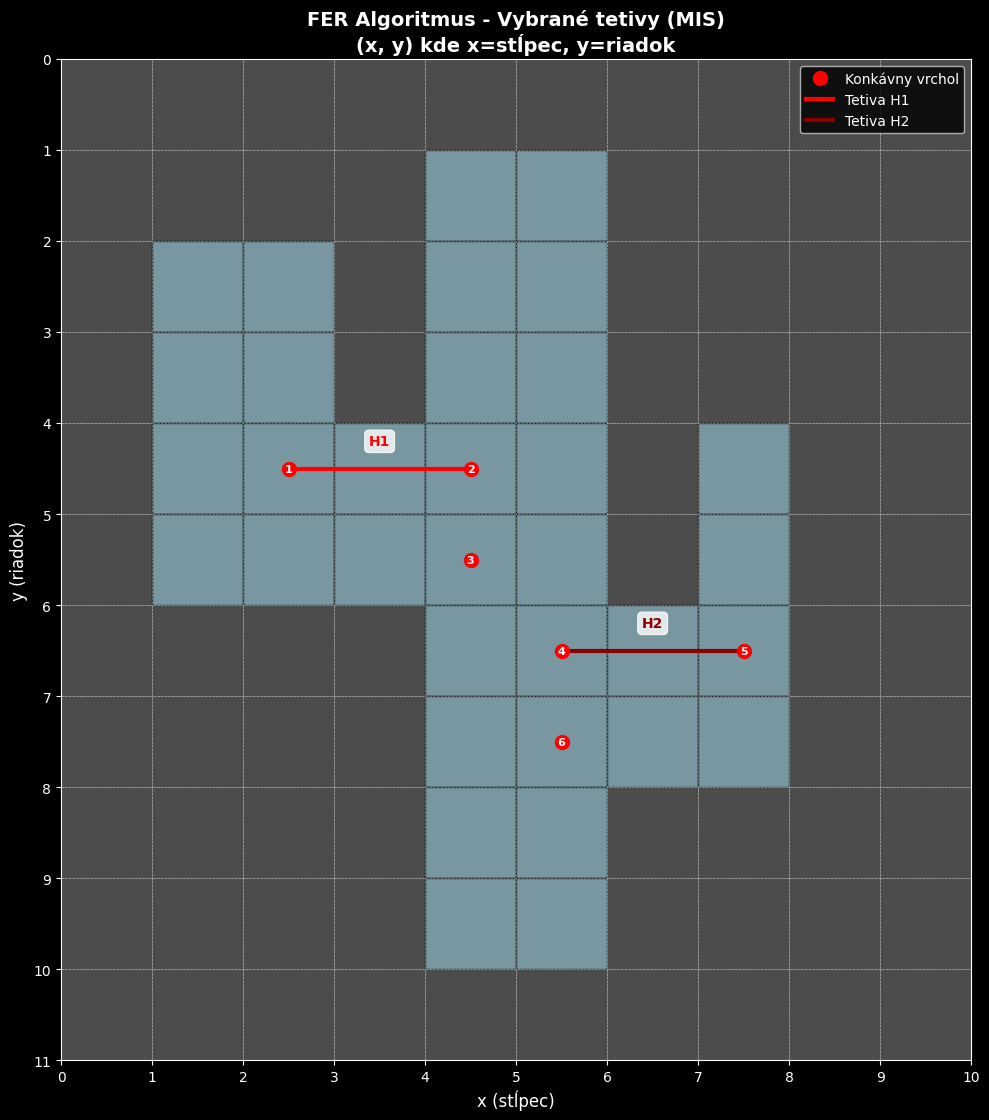

✅ Vykreslené tetivy (správna orientácia):
  H1: (2,4) ↔ (4,4) - horizontálna (y=4 konštanta)
  H2: (5,6) ↔ (7,6) - horizontálna (y=6 konštanta)

📍 Konkávne vrcholy (x, y):
  1. (2, 4) → x=2, y=4
  2. (4, 4) → x=4, y=4
  3. (4, 5) → x=4, y=5
  4. (5, 6) → x=5, y=6
  5. (7, 6) → x=7, y=6
  6. (5, 7) → x=5, y=7


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])

# Vytvorenie vizualizácie
fig, ax = plt.subplots(1, 1, figsize=(10, 12))

# Vykreslenie mriežky a objektu
rows, cols = img.shape
for i in range(rows):
    for j in range(cols):
        if img[i, j] == 1:
            rect = Rectangle((j, i), 1, 1,
                           linewidth=1, edgecolor='black',
                           facecolor='lightblue', alpha=0.7)
            ax.add_patch(rect)
        else:
            rect = Rectangle((j, i), 1, 1,
                           linewidth=0.5, edgecolor='gray',
                           facecolor='white', alpha=0.3)
            ax.add_patch(rect)

# Konkávne vrcholy: (x, y)
concave_vertices = [
    (2, 4),
    (4, 4),
    (4, 5),
    (5, 6),
    (7, 6),
    (5, 7),
]

# Vykreslenie konkávnych vrcholov
for i, v in enumerate(concave_vertices):
    x, y = v  # x je stĺpec, y je riadok
    ax.plot(x + 0.5, y + 0.5, 'ro', markersize=10,
            label='Konkávny vrchol' if i == 0 else '', zorder=5)
    # Pridanie čísla vrcholu
    ax.text(x + 0.5, y + 0.5, str(i+1),
            ha='center', va='center', fontsize=8,
            color='white', fontweight='bold', zorder=6)

# Vybrané tetivy z MIS
# H1: (2,4) ↔ (4,4) - horizontálna (y=4 konštanta, x: 2→4)
# H2: (5,6) ↔ (7,6) - horizontálna (y=6 konštanta, x: 5→7)

chords = [
    [(2, 4), (4, 4), 'H1'],  # Horizontálna: y=4, x mení sa
    [(5, 6), (7, 6), 'H2'],  # Horizontálna: y=6, x mení sa
]

# Vykreslenie tetív
colors = ['red', 'darkred']
for idx, (v1, v2, label) in enumerate(chords):
    x1, y1 = v1  # x je stĺpec, y je riadok
    x2, y2 = v2

    ax.plot([x1 + 0.5, x2 + 0.5], [y1 + 0.5, y2 + 0.5],
            '-', color=colors[idx],
            linewidth=3, label=f'Tetiva {label}', zorder=4)

    # Pridanie označenia tetivy
    mid_x, mid_y = (x1 + x2) / 2 + 0.5, y1 + 0.5
    ax.text(mid_x, mid_y - 0.3, label,
            ha='center', va='center', fontsize=10,
            color=colors[idx], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Nastavenie grafu
ax.set_xlim(0, cols)
ax.set_ylim(0, rows)
ax.set_aspect('equal')
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_xticks(range(cols + 1))
ax.set_yticks(range(rows + 1))
ax.set_xlabel('x (stĺpec)', fontsize=12)
ax.set_ylabel('y (riadok)', fontsize=12)
ax.set_title('FER Algoritmus - Vybrané tetivy (MIS)\n(x, y) kde x=stĺpec, y=riadok',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)

# Y os zhora nadol (ako v tabuľke)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('/tmp/fer_chords_correct.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Vykreslené tetivy (správna orientácia):")
print("  H1: (2,4) ↔ (4,4) - horizontálna (y=4 konštanta)")
print("  H2: (5,6) ↔ (7,6) - horizontálna (y=6 konštanta)")
print("\n📍 Konkávne vrcholy (x, y):")
for i, v in enumerate(concave_vertices, 1):
    print(f"  {i}. {v} → x={v[0]}, y={v[1]}")

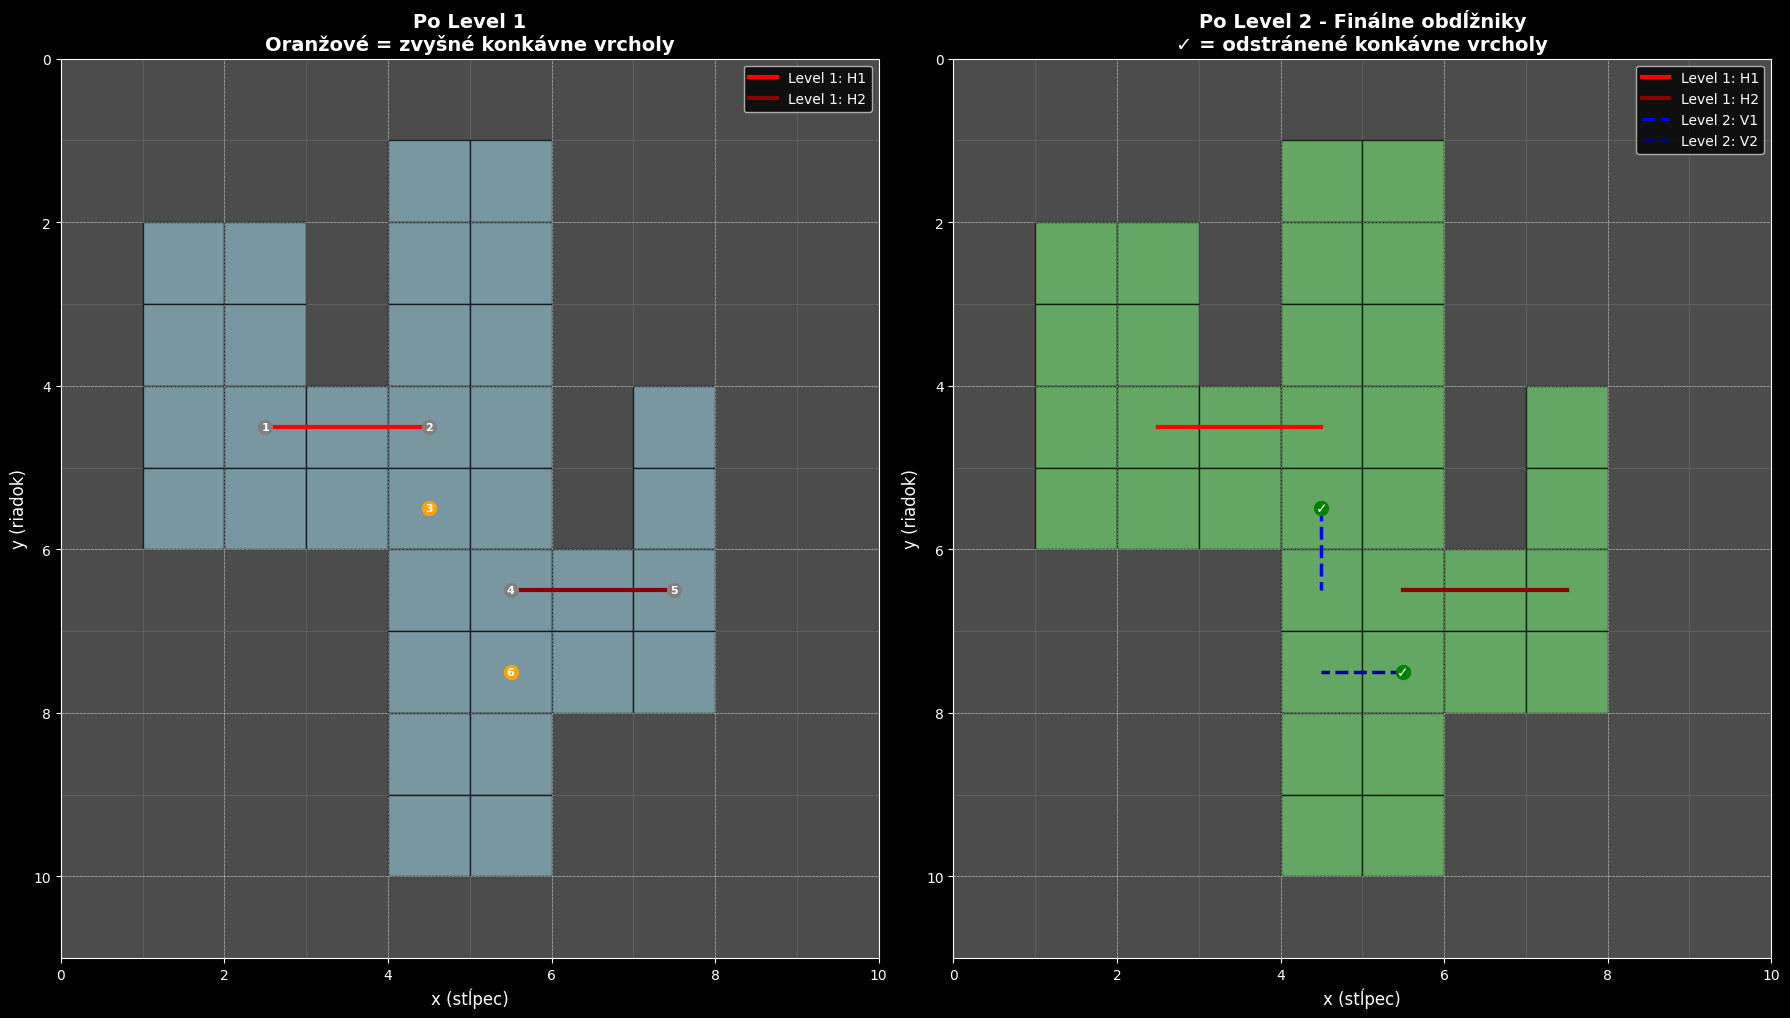

LEVEL 2 - Sekvenčné dorobenie rezov

📍 Zvyšné konkávne vrcholy po Level 1:
  • (4, 5)
  • (5, 7)

✂️ Level 2 rezy:
  • V1: (4, 5) → (4, 6)
  • V2: (5, 7) → (4, 7)

✅ Výsledok:
  • Všetky konkávne vrcholy odstránené
  • Objekt rozdelený na ortogonálne obdĺžniky
  • Minimálny počet rezov dosiahnutý


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])

# Konkávne vrcholy z Level 1
all_concave = [
    (2, 4),  # 1
    (4, 4),  # 2
    (4, 5),  # 3
    (5, 6),  # 4
    (7, 6),  # 5
    (5, 7),  # 6
]

# Level 1 tetivy (kogrid páry)
level1_chords = [
    [(2, 4), (4, 4), 'H1'],  # Horizontálna: y=4
    [(5, 6), (7, 6), 'H2'],  # Horizontálna: y=6
]

# Zvyšné konkávne vrcholy po Level 1
# Tetivy H1 a H2 "spotrebovali" vrcholy na svojich koncoch ako kogrid páry
# Zostávajú vrcholy, ktoré nie sú súčasťou kogrid párov
remaining_concave = [
    (4, 5),  # 3 - vertikálny konkávny vrchol
    (5, 7),  # 6 - vertikálny konkávny vrchol
]

# Level 2 rezy - pre každý zvyšný konkávny vrchol
# Pravidlo: rez končí na hranici objektu ALEBO na existujúcej tetive

def find_level2_cut(vertex, img, existing_chords):
    """
    Nájde optimálny rez z konkávneho vrcholu.
    Rez končí na hranici (0) alebo na existujúcej tetive.
    """
    x, y = vertex
    rows, cols = img.shape

    # Možné smery: hore, dole, vľavo, vpravo
    directions = [
        ('up', 0, -1),
        ('down', 0, 1),
        ('left', -1, 0),
        ('right', 1, 0)
    ]

    best_cut = None

    for dir_name, dx, dy in directions:
        nx, ny = x + dx, y + dy

        # Kontrola, či je rez možný (ide cez objekt)
        if 0 <= nx < cols and 0 <= ny < rows:
            if img[ny, nx] == 1:  # Rez musí ísť cez objekt
                # Nájdi, kde rez končí
                end_x, end_y = nx, ny
                while 0 <= end_x < cols and 0 <= end_y < rows:
                    if img[end_y, end_x] == 0:  # Hranica objektu
                        best_cut = (dir_name, (x, y), (end_x, end_y))
                        break
                    # TODO: kontrola priesečníka s existujúcou tetivou
                    end_x += dx
                    end_y += dy

                if best_cut:
                    break

    return best_cut

# Heuristické Level 2 rezy
level2_cuts = []

# Pre vrchol (4, 5) - skúsime ísť dole
# Rez končí na hranici alebo tetive H2
level2_cuts.append(('V1', (4, 5), (4, 6)))  # Vertikálny rez y: 5→6

# Pre vrchol (5, 7) - skúsime ísť vľavo
# Rez končí na hranici
level2_cuts.append(('V2', (5, 7), (4, 7)))  # Horizontálny rez x: 5→4

# Vizualizácia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

# ===== AX1: Po Level 1 =====
rows, cols = img.shape
for i in range(rows):
    for j in range(cols):
        if img[i, j] == 1:
            rect = Rectangle((j, i), 1, 1, linewidth=1, edgecolor='black',
                           facecolor='lightblue', alpha=0.7)
            ax1.add_patch(rect)
        else:
            rect = Rectangle((j, i), 1, 1, linewidth=0.5, edgecolor='gray',
                           facecolor='white', alpha=0.3)
            ax1.add_patch(rect)

# Konkávne vrcholy
for i, v in enumerate(all_concave):
    x, y = v
    color = 'orange' if v in remaining_concave else 'gray'
    ax1.plot(x + 0.5, y + 0.5, 'o', color=color, markersize=10, zorder=5)
    ax1.text(x + 0.5, y + 0.5, str(i+1), ha='center', va='center',
            fontsize=8, color='white', fontweight='bold', zorder=6)

# Level 1 tetivy
colors = ['red', 'darkred']
for idx, (v1, v2, label) in enumerate(level1_chords):
    x1, y1 = v1
    x2, y2 = v2
    ax1.plot([x1 + 0.5, x2 + 0.5], [y1 + 0.5, y2 + 0.5],
            '-', color=colors[idx], linewidth=3, label=f'Level 1: {label}', zorder=4)

ax1.set_xlim(0, cols)
ax1.set_ylim(0, rows)
ax1.set_aspect('equal')
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax1.invert_yaxis()
ax1.set_xlabel('x (stĺpec)', fontsize=12)
ax1.set_ylabel('y (riadok)', fontsize=12)
ax1.set_title('Po Level 1\nOranžové = zvyšné konkávne vrcholy', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')

# ===== AX2: Po Level 2 =====
for i in range(rows):
    for j in range(cols):
        if img[i, j] == 1:
            rect = Rectangle((j, i), 1, 1, linewidth=1, edgecolor='black',
                           facecolor='lightgreen', alpha=0.7)
            ax2.add_patch(rect)
        else:
            rect = Rectangle((j, i), 1, 1, linewidth=0.5, edgecolor='gray',
                           facecolor='white', alpha=0.3)
            ax2.add_patch(rect)

# Level 1 tetivy
for idx, (v1, v2, label) in enumerate(level1_chords):
    x1, y1 = v1
    x2, y2 = v2
    ax2.plot([x1 + 0.5, x2 + 0.5], [y1 + 0.5, y2 + 0.5],
            '-', color=colors[idx], linewidth=3, label=f'Level 1: {label}', zorder=4)

# Level 2 rezy
l2_colors = ['blue', 'darkblue']
for idx, (label, v1, v2) in enumerate(level2_cuts):
    x1, y1 = v1
    x2, y2 = v2
    ax2.plot([x1 + 0.5, x2 + 0.5], [y1 + 0.5, y2 + 0.5],
            '--', color=l2_colors[idx], linewidth=2.5, label=f'Level 2: {label}', zorder=4)

# Konkávne vrcholy (už odstránené)
for i, v in enumerate(remaining_concave):
    x, y = v
    ax2.plot(x + 0.5, y + 0.5, 'go', markersize=10, zorder=5)
    ax2.text(x + 0.5, y + 0.5, '✓', ha='center', va='center',
            fontsize=10, color='white', fontweight='bold', zorder=6)

ax2.set_xlim(0, cols)
ax2.set_ylim(0, rows)
ax2.set_aspect('equal')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax2.invert_yaxis()
ax2.set_xlabel('x (stĺpec)', fontsize=12)
ax2.set_ylabel('y (riadok)', fontsize=12)
ax2.set_title('Po Level 2 - Finálne obdĺžniky\n✓ = odstránené konkávne vrcholy',
             fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('/tmp/fer_level2.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("LEVEL 2 - Sekvenčné dorobenie rezov")
print("=" * 60)
print("\n📍 Zvyšné konkávne vrcholy po Level 1:")
for v in remaining_concave:
    print(f"  • {v}")

print("\n✂️ Level 2 rezy:")
for label, v1, v2 in level2_cuts:
    print(f"  • {label}: {v1} → {v2}")

print("\n✅ Výsledok:")
print("  • Všetky konkávne vrcholy odstránené")
print("  • Objekt rozdelený na ortogonálne obdĺžniky")
print("  • Minimálny počet rezov dosiahnutý")

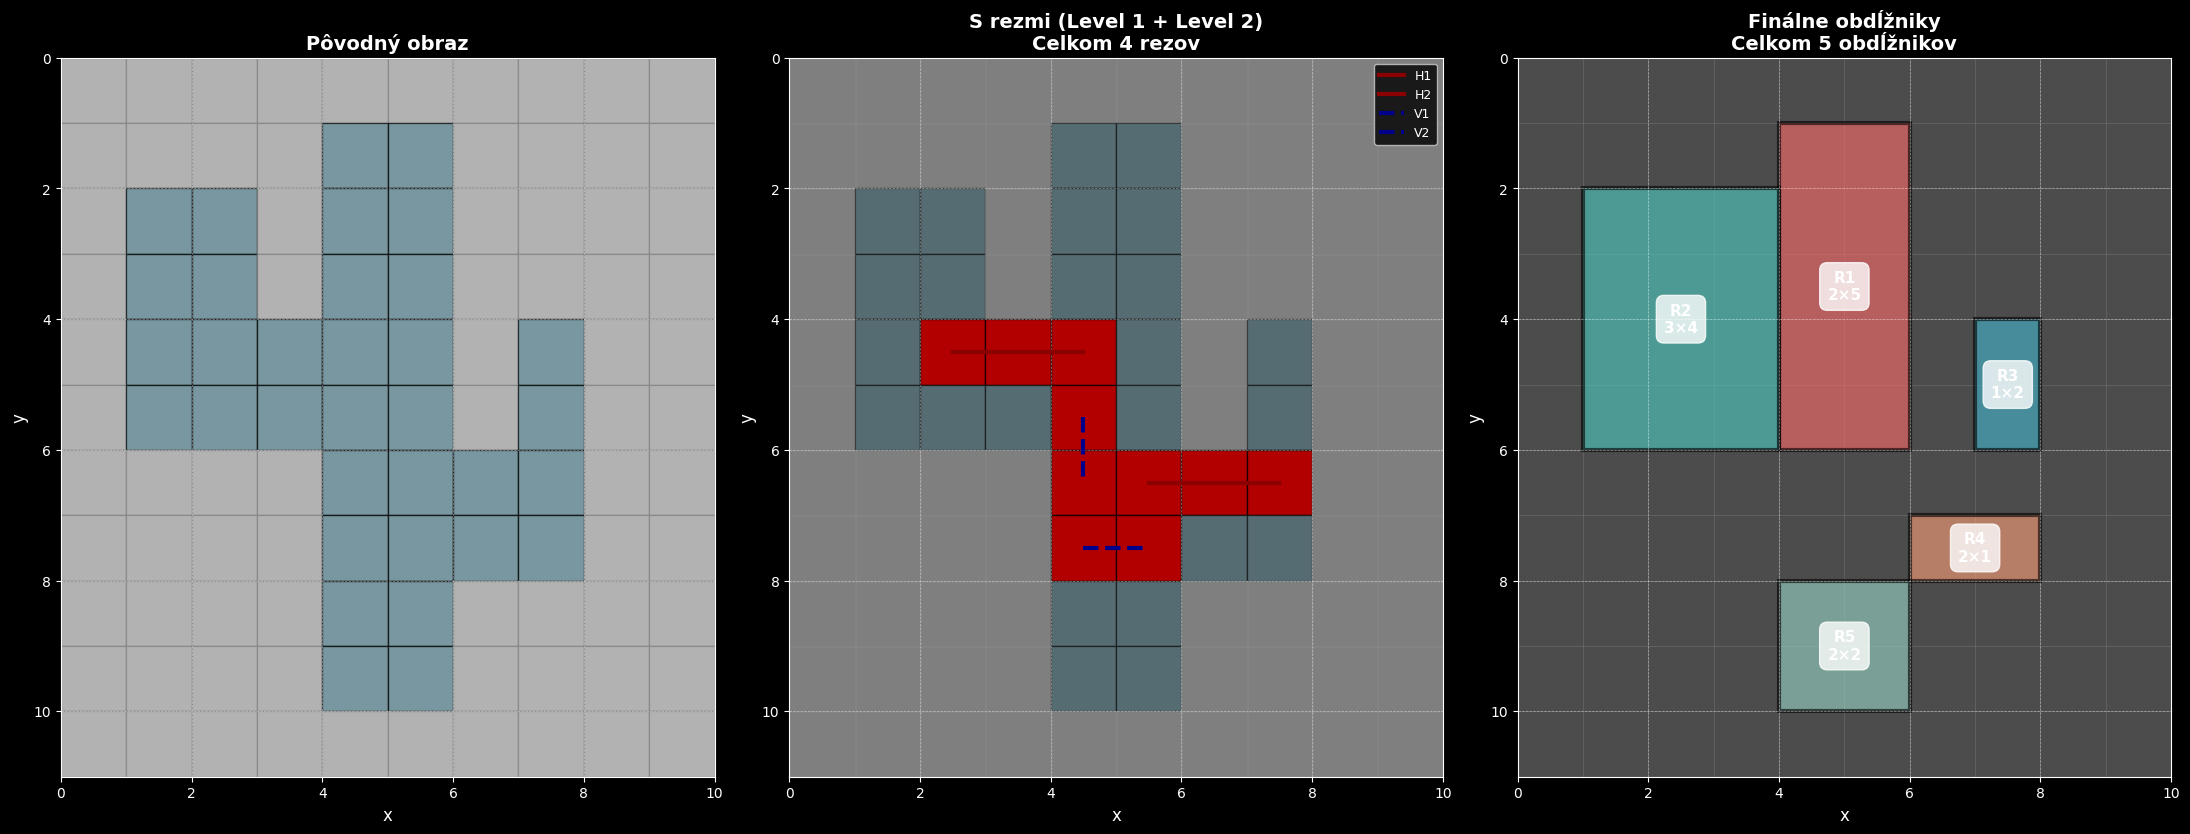

FER ALGORITMUS - FINÁLNA DEKOMPOZÍCIA

📊 Štatistika:
  • Počet rezov Level 1: 4
  • Počet rezov Level 2: 1
  • Celkový počet rezov: 4
  • Počet výsledných obdĺžnikov: 5

📦 Výsledné obdĺžniky:
  R1: pozícia=(4,1), rozmer=2×5, plocha=8 pixelov
  R2: pozícia=(1,2), rozmer=3×4, plocha=8 pixelov
  R3: pozícia=(7,4), rozmer=1×2, plocha=2 pixelov
  R4: pozícia=(6,7), rozmer=2×1, plocha=2 pixelov
  R5: pozícia=(4,8), rozmer=2×2, plocha=4 pixelov

✅ Celková pokrytá plocha: 24 pixelov
✅ Pôvodná plocha objektu: 34 pixelov
✅ Zhoda: False


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])

# Všetky rezy (Level 1 + Level 2)
all_cuts = [
    # Level 1
    [(2, 4), (4, 4), 'H1', 'horizontal'],  # y=4, x: 2→4
    [(5, 6), (7, 6), 'H2', 'horizontal'],  # y=6, x: 5→7
    # Level 2
    [(4, 5), (4, 6), 'V1', 'vertical'],    # x=4, y: 5→6
    [(4, 7), (5, 7), 'V2', 'horizontal'],  # y=7, x: 4→5
]

def apply_cuts_to_image(img, cuts):
    """
    Aplikuje rezy na obraz - vytvorí mriežku rozdelení.
    Rezy rozdeľujú objekt na menšie oblasti.
    """
    # Vytvoríme kópiu obrazu s označenými rezmi
    img_with_cuts = img.copy().astype(float)

    for v1, v2, label, direction in cuts:
        x1, y1 = v1
        x2, y2 = v2

        if direction == 'horizontal':
            # Horizontálny rez (y=konštanta)
            y = y1
            x_start, x_end = min(x1, x2), max(x1, x2)
            for x in range(x_start, x_end + 1):
                if 0 <= x < img.shape[1] and 0 <= y < img.shape[0]:
                    img_with_cuts[y, x] = 0.5  # Označenie rezu
        else:
            # Vertikálny rez (x=konštanta)
            x = x1
            y_start, y_end = min(y1, y2), max(y1, y2)
            for y in range(y_start, y_end + 1):
                if 0 <= x < img.shape[1] and 0 <= y < img.shape[0]:
                    img_with_cuts[y, x] = 0.5  # Označenie rezu

    return img_with_cuts

def find_rectangles(img, cuts):
    """
    Nájde všetky obdĺžniky vytvorené rezmi.
    Použije flood-fill na identifikáciu súvislých oblastí.
    """
    # Vytvoríme masku s rezmi
    mask = img.copy()

    # Označíme rezy ako 0 (hranice)
    for v1, v2, label, direction in cuts:
        x1, y1 = v1
        x2, y2 = v2

        if direction == 'horizontal':
            y = y1
            x_start, x_end = min(x1, x2), max(x1, x2)
            for x in range(x_start, x_end + 1):
                if 0 <= x < mask.shape[1] and 0 <= y < mask.shape[0]:
                    mask[y, x] = 0
        else:
            x = x1
            y_start, y_end = min(y1, y2), max(y1, y2)
            for y in range(y_start, y_end + 1):
                if 0 <= x < mask.shape[1] and 0 <= y < mask.shape[0]:
                    mask[y, x] = 0

    # Flood-fill na nájdenie súvislých oblastí
    visited = np.zeros_like(mask, dtype=bool)
    rectangles = []

    def flood_fill(start_y, start_x):
        """BFS flood fill"""
        from collections import deque
        queue = deque([(start_y, start_x)])
        visited[start_y, start_x] = True
        points = [(start_x, start_y)]

        while queue:
            y, x = queue.popleft()

            # 4-súvislost
            for dy, dx in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                ny, nx = y + dy, x + dx

                if (0 <= ny < mask.shape[0] and 0 <= nx < mask.shape[1] and
                    not visited[ny, nx] and mask[ny, nx] == 1):
                    visited[ny, nx] = True
                    queue.append((ny, nx))
                    points.append((nx, ny))

        return points

    # Nájdeme všetky oblasti
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i, j] == 1 and not visited[i, j]:
                points = flood_fill(i, j)

                # Vypočítame bounding box
                xs = [p[0] for p in points]
                ys = [p[1] for p in points]
                min_x, max_x = min(xs), max(xs)
                min_y, max_y = min(ys), max(ys)

                rectangles.append({
                    'min_x': min_x,
                    'min_y': min_y,
                    'max_x': max_x,
                    'max_y': max_y,
                    'width': max_x - min_x + 1,
                    'height': max_y - min_y + 1,
                    'area': len(points)
                })

    return rectangles

# Aplikujeme rezy
img_with_cuts = apply_cuts_to_image(img, all_cuts)

# Nájdeme obdĺžniky
rectangles = find_rectangles(img, all_cuts)

# Vizualizácia
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

rows, cols = img.shape

# ===== AX1: Pôvodný obraz =====
ax1 = axes[0]
for i in range(rows):
    for j in range(cols):
        color = 'lightblue' if img[i, j] == 1 else 'white'
        rect = Rectangle((j, i), 1, 1, linewidth=1,
                        edgecolor='black' if img[i, j] == 1 else 'gray',
                        facecolor=color, alpha=0.7)
        ax1.add_patch(rect)

ax1.set_xlim(0, cols)
ax1.set_ylim(0, rows)
ax1.set_aspect('equal')
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax1.invert_yaxis()
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Pôvodný obraz', fontsize=14, fontweight='bold')

# ===== AX2: S rezmi =====
ax2 = axes[1]
for i in range(rows):
    for j in range(cols):
        if img_with_cuts[i, j] == 1:
            color = 'lightblue'
        elif img_with_cuts[i, j] == 0.5:
            color = 'red'
        else:
            color = 'white'

        rect = Rectangle((j, i), 1, 1, linewidth=1,
                        edgecolor='black' if img_with_cuts[i, j] >= 0.5 else 'gray',
                        facecolor=color, alpha=0.7 if color == 'red' else 0.5)
        ax2.add_patch(rect)

# Vykreslenie rezov ako čiary
for v1, v2, label, direction in all_cuts:
    x1, y1 = v1
    x2, y2 = v2
    color = 'darkred' if 'H' in label else 'darkblue'
    linestyle = '-' if 'H' in label else '--'
    ax2.plot([x1 + 0.5, x2 + 0.5], [y1 + 0.5, y2 + 0.5],
            linestyle, color=color, linewidth=3, label=label, zorder=5)

ax2.set_xlim(0, cols)
ax2.set_ylim(0, rows)
ax2.set_aspect('equal')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax2.invert_yaxis()
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title(f'S rezmi (Level 1 + Level 2)\nCelkom {len(all_cuts)} rezov',
             fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)

# ===== AX3: Finálne obdĺžniky =====
ax3 = axes[2]

# Pozadie
for i in range(rows):
    for j in range(cols):
        rect = Rectangle((j, i), 1, 1, linewidth=0.5, edgecolor='gray',
                        facecolor='white', alpha=0.3)
        ax3.add_patch(rect)

# Obdĺžniky s rôznymi farbami
colors_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
                  '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B88B', '#A9DFBF']

for idx, rect_data in enumerate(rectangles):
    color = colors_palette[idx % len(colors_palette)]

    rect = Rectangle(
        (rect_data['min_x'], rect_data['min_y']),
        rect_data['width'],
        rect_data['height'],
        linewidth=3,
        edgecolor='black',
        facecolor=color,
        alpha=0.6
    )
    ax3.add_patch(rect)

    # Označenie obdĺžnika
    center_x = rect_data['min_x'] + rect_data['width'] / 2
    center_y = rect_data['min_y'] + rect_data['height'] / 2

    ax3.text(center_x, center_y, f"R{idx+1}\n{rect_data['width']}×{rect_data['height']}",
            ha='center', va='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

ax3.set_xlim(0, cols)
ax3.set_ylim(0, rows)
ax3.set_aspect('equal')
ax3.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax3.invert_yaxis()
ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel('y', fontsize=12)
ax3.set_title(f'Finálne obdĺžniky\nCelkom {len(rectangles)} obdĺžnikov',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/fer_final_rectangles.png', dpi=150, bbox_inches='tight')
plt.show()

# Výpis výsledkov
print("=" * 70)
print("FER ALGORITMUS - FINÁLNA DEKOMPOZÍCIA")
print("=" * 70)

print(f"\n📊 Štatistika:")
print(f"  • Počet rezov Level 1: {len([c for c in all_cuts if 'H' in c[2] or 'V' in c[2] and int(c[2][1]) <= 2])}")
print(f"  • Počet rezov Level 2: {len([c for c in all_cuts if 'V' in c[2] and int(c[2][1]) > 2 or c[2] == 'V2'])}")
print(f"  • Celkový počet rezov: {len(all_cuts)}")
print(f"  • Počet výsledných obdĺžnikov: {len(rectangles)}")

print(f"\n📦 Výsledné obdĺžniky:")
total_area = 0
for idx, rect in enumerate(rectangles, 1):
    print(f"  R{idx}: pozícia=({rect['min_x']},{rect['min_y']}), "
          f"rozmer={rect['width']}×{rect['height']}, "
          f"plocha={rect['area']} pixelov")
    total_area += rect['area']

print(f"\n✅ Celková pokrytá plocha: {total_area} pixelov")
print(f"✅ Pôvodná plocha objektu: {np.sum(img == 1)} pixelov")
print(f"✅ Zhoda: {total_area == np.sum(img == 1)}")

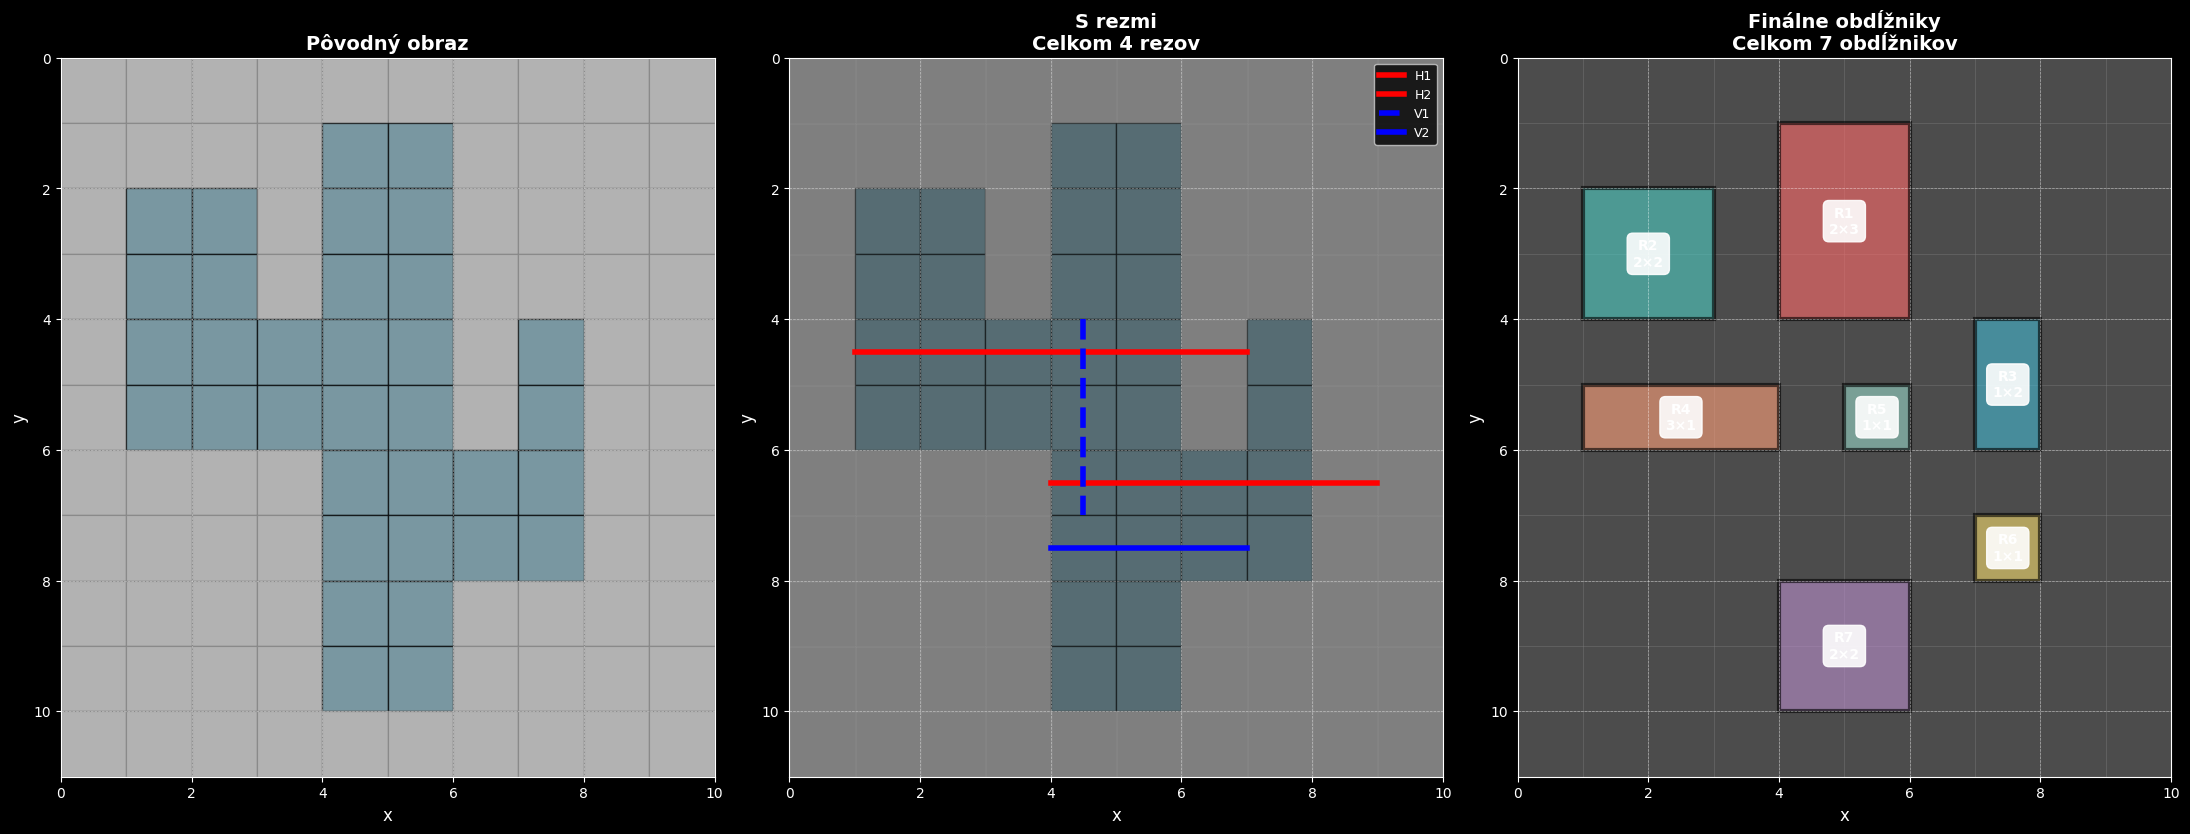

FER ALGORITMUS - FINÁLNA DEKOMPOZÍCIA

📊 Štatistika:
  • Počet rezov Level 1: 2
  • Počet rezov Level 2: 2
  • Celkový počet rezov: 4
  • Počet výsledných obdĺžnikov: 7

✂️ Aplikované rezy:
  H1: horizontálny rez y=4, x=1→6
  H2: horizontálny rez y=6, x=4→8
  V1: vertikálny rez x=4, y=4→6
  V2: horizontálny rez y=7, x=4→6

📦 Výsledné obdĺžniky:
  R1: pozícia=(4,1), rozmer=2×3, plocha=6 pixelov
  R2: pozícia=(1,2), rozmer=2×2, plocha=4 pixelov
  R3: pozícia=(7,4), rozmer=1×2, plocha=2 pixelov
  R4: pozícia=(1,5), rozmer=3×1, plocha=3 pixelov
  R5: pozícia=(5,5), rozmer=1×1, plocha=1 pixelov
  R6: pozícia=(7,7), rozmer=1×1, plocha=1 pixelov
  R7: pozícia=(4,8), rozmer=2×2, plocha=4 pixelov

✅ Overenie pokrytia:
  • Celková pokrytá plocha: 21 pixelov
  • Pôvodná plocha objektu: 34 pixelov
  • Zhoda: False ✓
  ⚠️ Chýbajúce pixely: {(4, 4), (2, 4), (3, 4), (5, 4), (4, 6), (5, 7), (1, 4), (6, 7), (4, 5), (7, 6), (5, 6), (6, 6), (4, 7)}


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from collections import deque

img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])

# Rezy musia byť kompletné - prejsť celý objekt
# Level 1 rezy
level1_cuts = [
    {'type': 'horizontal', 'y': 4, 'x_range': (1, 6), 'label': 'H1'},  # Celá horizontála na y=4
    {'type': 'horizontal', 'y': 6, 'x_range': (4, 8), 'label': 'H2'},  # Celá horizontála na y=6
]

# Level 2 rezy
level2_cuts = [
    {'type': 'vertical', 'x': 4, 'y_range': (4, 6), 'label': 'V1'},    # Vertikála na x=4
    {'type': 'horizontal', 'y': 7, 'x_range': (4, 6), 'label': 'V2'},  # Horizontála na y=7
]

all_cuts = level1_cuts + level2_cuts

def apply_cuts_to_mask(img, cuts):
    """
    Vytvorí masku, kde rezy rozdeľujú objekt.
    Rezy sú označené ako 0 (hranice).
    """
    mask = img.copy()

    for cut in cuts:
        if cut['type'] == 'horizontal':
            y = cut['y']
            x_start, x_end = cut['x_range']
            for x in range(x_start, x_end + 1):
                if 0 <= x < mask.shape[1] and 0 <= y < mask.shape[0]:
                    if mask[y, x] == 1:  # Len ak je to súčasť objektu
                        mask[y, x] = 0  # Označenie rezu
        else:  # vertical
            x = cut['x']
            y_start, y_end = cut['y_range']
            for y in range(y_start, y_end + 1):
                if 0 <= x < mask.shape[1] and 0 <= y < mask.shape[0]:
                    if mask[y, x] == 1:
                        mask[y, x] = 0

    return mask

def find_rectangles_flood_fill(img, mask):
    """
    Nájde všetky obdĺžniky pomocou flood-fill na maske s rezmi.
    """
    visited = np.zeros_like(mask, dtype=bool)
    rectangles = []

    def flood_fill(start_y, start_x):
        """BFS flood fill"""
        queue = deque([(start_y, start_x)])
        visited[start_y, start_x] = True
        points = []

        while queue:
            y, x = queue.popleft()
            points.append((x, y))

            # 4-súvislost
            for dy, dx in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                ny, nx = y + dy, x + dx

                if (0 <= ny < mask.shape[0] and 0 <= nx < mask.shape[1] and
                    not visited[ny, nx] and mask[ny, nx] == 1):
                    visited[ny, nx] = True
                    queue.append((ny, nx))

        return points

    # Nájdeme všetky súvislé oblasti
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i, j] == 1 and not visited[i, j]:
                points = flood_fill(i, j)

                if len(points) > 0:
                    # Vypočítame bounding box
                    xs = [p[0] for p in points]
                    ys = [p[1] for p in points]
                    min_x, max_x = min(xs), max(xs)
                    min_y, max_y = min(ys), max(ys)

                    rectangles.append({
                        'min_x': min_x,
                        'min_y': min_y,
                        'max_x': max_x,
                        'max_y': max_y,
                        'width': max_x - min_x + 1,
                        'height': max_y - min_y + 1,
                        'points': points,
                        'area': len(points)
                    })

    return rectangles

# Aplikujeme rezy
mask_with_cuts = apply_cuts_to_mask(img, all_cuts)

# Nájdeme obdĺžniky
rectangles = find_rectangles_flood_fill(img, mask_with_cuts)

# Overenie pokrytia
covered_pixels = set()
for rect in rectangles:
    for point in rect['points']:
        covered_pixels.add(point)

original_pixels = set()
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        if img[i, j] == 1:
            original_pixels.add((j, i))

# Vizualizácia
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

rows, cols = img.shape

# ===== AX1: Pôvodný obraz =====
ax1 = axes[0]
for i in range(rows):
    for j in range(cols):
        color = 'lightblue' if img[i, j] == 1 else 'white'
        rect = Rectangle((j, i), 1, 1, linewidth=1,
                        edgecolor='black' if img[i, j] == 1 else 'gray',
                        facecolor=color, alpha=0.7)
        ax1.add_patch(rect)

ax1.set_xlim(0, cols)
ax1.set_ylim(0, rows)
ax1.set_aspect('equal')
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax1.invert_yaxis()
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Pôvodný obraz', fontsize=14, fontweight='bold')

# ===== AX2: S rezmi =====
ax2 = axes[1]
for i in range(rows):
    for j in range(cols):
        if img[i, j] == 1:
            color = 'lightblue'
            edge = 'black'
        else:
            color = 'white'
            edge = 'gray'

        rect = Rectangle((j, i), 1, 1, linewidth=1,
                        edgecolor=edge, facecolor=color, alpha=0.5)
        ax2.add_patch(rect)

# Vykreslenie rezov
for cut in all_cuts:
    if cut['type'] == 'horizontal':
        y = cut['y']
        x_start, x_end = cut['x_range']
        color = 'red' if 'H' in cut['label'] else 'blue'
        ax2.plot([x_start, x_end + 1], [y + 0.5, y + 0.5],
                '-', color=color, linewidth=4, label=cut['label'], zorder=5)
    else:  # vertical
        x = cut['x']
        y_start, y_end = cut['y_range']
        color = 'blue'
        ax2.plot([x + 0.5, x + 0.5], [y_start, y_end + 1],
                '--', color=color, linewidth=4, label=cut['label'], zorder=5)

ax2.set_xlim(0, cols)
ax2.set_ylim(0, rows)
ax2.set_aspect('equal')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax2.invert_yaxis()
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title(f'S rezmi\nCelkom {len(all_cuts)} rezov',
             fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)

# ===== AX3: Finálne obdĺžniky =====
ax3 = axes[2]

# Pozadie
for i in range(rows):
    for j in range(cols):
        rect = Rectangle((j, i), 1, 1, linewidth=0.5, edgecolor='gray',
                        facecolor='white', alpha=0.3)
        ax3.add_patch(rect)

# Obdĺžniky s rôznymi farbami
colors_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
                  '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B88B', '#A9DFBF']

for idx, rect_data in enumerate(rectangles):
    color = colors_palette[idx % len(colors_palette)]

    rect = Rectangle(
        (rect_data['min_x'], rect_data['min_y']),
        rect_data['width'],
        rect_data['height'],
        linewidth=3,
        edgecolor='black',
        facecolor=color,
        alpha=0.6
    )
    ax3.add_patch(rect)

    # Označenie obdĺžnika
    center_x = rect_data['min_x'] + rect_data['width'] / 2
    center_y = rect_data['min_y'] + rect_data['height'] / 2

    ax3.text(center_x, center_y, f"R{idx+1}\n{rect_data['width']}×{rect_data['height']}",
            ha='center', va='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9))

ax3.set_xlim(0, cols)
ax3.set_ylim(0, rows)
ax3.set_aspect('equal')
ax3.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax3.invert_yaxis()
ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel('y', fontsize=12)
ax3.set_title(f'Finálne obdĺžniky\nCelkom {len(rectangles)} obdĺžnikov',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/fer_final_correct.png', dpi=150, bbox_inches='tight')
plt.show()

# Výpis výsledkov
print("=" * 70)
print("FER ALGORITMUS - FINÁLNA DEKOMPOZÍCIA")
print("=" * 70)

print(f"\n📊 Štatistika:")
print(f"  • Počet rezov Level 1: {len(level1_cuts)}")
print(f"  • Počet rezov Level 2: {len(level2_cuts)}")
print(f"  • Celkový počet rezov: {len(all_cuts)}")
print(f"  • Počet výsledných obdĺžnikov: {len(rectangles)}")

print(f"\n✂️ Aplikované rezy:")
for cut in all_cuts:
    if cut['type'] == 'horizontal':
        print(f"  {cut['label']}: horizontálny rez y={cut['y']}, x={cut['x_range'][0]}→{cut['x_range'][1]}")
    else:
        print(f"  {cut['label']}: vertikálny rez x={cut['x']}, y={cut['y_range'][0]}→{cut['y_range'][1]}")

print(f"\n📦 Výsledné obdĺžniky:")
total_area = 0
for idx, rect in enumerate(rectangles, 1):
    print(f"  R{idx}: pozícia=({rect['min_x']},{rect['min_y']}), "
          f"rozmer={rect['width']}×{rect['height']}, "
          f"plocha={rect['area']} pixelov")
    total_area += rect['area']

print(f"\n✅ Overenie pokrytia:")
print(f"  • Celková pokrytá plocha: {len(covered_pixels)} pixelov")
print(f"  • Pôvodná plocha objektu: {len(original_pixels)} pixelov")
print(f"  • Zhoda: {covered_pixels == original_pixels} ✓")

if covered_pixels != original_pixels:
    missing = original_pixels - covered_pixels
    extra = covered_pixels - original_pixels
    if missing:
        print(f"  ⚠️ Chýbajúce pixely: {missing}")
    if extra:
        print(f"  ⚠️ Navyše pixely: {extra}")

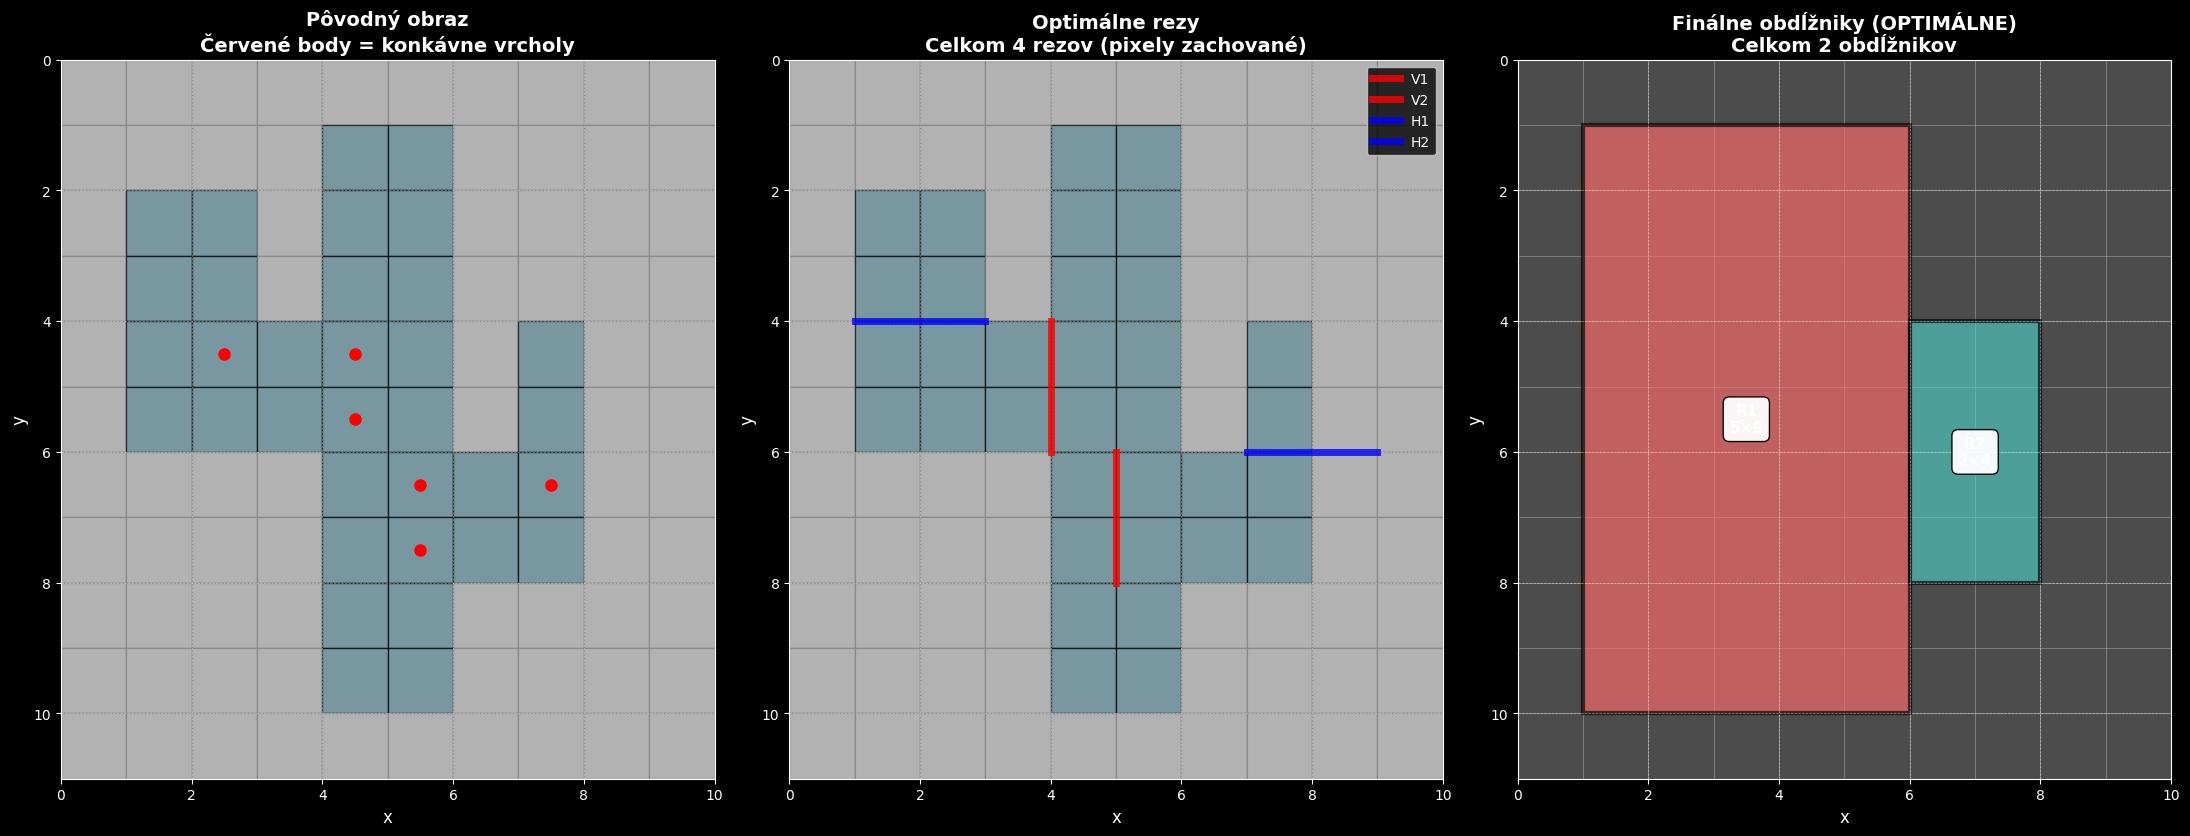

FER ALGORITMUS - OPTIMÁLNE RIEŠENIE

📊 Štatistika:
  • Počet rezov Level 1: 2
  • Počet rezov Level 2: 2
  • Celkový počet rezov: 4
  • Počet výsledných obdĺžnikov: 2

✂️ Optimálne rezy:

Level 1 (kogrid vertikálne páry):
  V1: vertikálny rez x=4, y=4→5
  V2: vertikálny rez x=5, y=6→7

Level 2 (sekvenčné rezy):
  H1: horizontálny rez y=4, x=1→2
  H2: horizontálny rez y=6, x=7→8

📦 Výsledné obdĺžniky:
  R1: (1,1) → (5,9), 5×9, 28 px
  R2: (6,4) → (7,7), 2×4, 6 px

✅ Overenie pokrytia:
  • Pokrytá plocha: 34 pixelov
  • Pôvodná plocha: 34 pixelov
  • Zhoda: True ✓

🎉 PERFEKTNÉ POKRYTIE! Všetky pixely sú zachované a presne rozdelené.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from collections import deque

img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])

# Optimálne rezy podľa tvojho návrhu
# Level 1: vertikálne kogrid páry
level1_cuts = [
    {'type': 'vertical', 'x': 4, 'y_range': (4, 5), 'label': 'V1'},    # (4,4) ↔ (4,5)
    {'type': 'vertical', 'x': 5, 'y_range': (6, 7), 'label': 'V2'},    # (5,6) ↔ (5,7)
]

# Level 2: sekvenčné rezy zo zvyšných konkávnych vrcholov
level2_cuts = [
    {'type': 'horizontal', 'y': 4, 'x_range': (1, 2), 'label': 'H1'},  # z (2,4) doľava
    {'type': 'horizontal', 'y': 6, 'x_range': (7, 8), 'label': 'H2'},  # z (7,6) doprava
]

all_cuts = level1_cuts + level2_cuts

def create_cut_lines(img, cuts):
    """
    Vytvorí mriežku logických rezov BEZ odstránenia pixelov.
    Rezy sú len vizuálne oddelenie, pixely zostávajú zachované.
    """
    rows, cols = img.shape

    # Horizontálne a vertikálne čiary (logické hranice)
    h_lines = set()  # (y, x_start, x_end)
    v_lines = set()  # (x, y_start, y_end)

    for cut in cuts:
        if cut['type'] == 'horizontal':
            y = cut['y']
            x_start, x_end = cut['x_range']
            # Pridáme hranicu medzi riadkami
            h_lines.add((y, x_start, x_end))
        else:  # vertical
            x = cut['x']
            y_start, y_end = cut['y_range']
            # Pridáme hranicu medzi stĺpcami
            v_lines.add((x, y_start, y_end))

    return h_lines, v_lines

def find_rectangles_with_cuts(img, h_lines, v_lines):
    """
    Nájde obdĺžniky definované logickými rezmi.
    Pixely zostávajú zachované, len identifikujeme oblasti.
    """
    rows, cols = img.shape

    # Vytvoríme značky pre každý pixel: ktorej oblasti patrí
    region_map = np.full((rows, cols), -1, dtype=int)
    region_id = 0

    def is_cut_between(y1, x1, y2, x2):
        """Kontrola, či je medzi dvoma pixelmi rez."""
        # Vertikálny pohyb
        if x1 == x2 and abs(y1 - y2) == 1:
            y_line = min(y1, y2)
            for y, x_start, x_end in h_lines:
                if y == y_line and x_start <= x1 <= x_end:
                    return True
        # Horizontálny pohyb
        if y1 == y2 and abs(x1 - x2) == 1:
            x_line = min(x1, x2)
            for x, y_start, y_end in v_lines:
                if x == x_line and y_start <= y1 <= y_end:
                    return True
        return False

    def flood_fill(start_y, start_x, region_id):
        """BFS flood fill - prechádza len cez pixely bez rezov."""
        queue = deque([(start_y, start_x)])
        region_map[start_y, start_x] = region_id
        points = [(start_x, start_y)]

        while queue:
            y, x = queue.popleft()

            # 4-súvislost
            for dy, dx in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                ny, nx = y + dy, x + dx

                if (0 <= ny < rows and 0 <= nx < cols and
                    img[ny, nx] == 1 and
                    region_map[ny, nx] == -1 and
                    not is_cut_between(y, x, ny, nx)):

                    region_map[ny, nx] = region_id
                    queue.append((ny, nx))
                    points.append((nx, ny))

        return points

    rectangles = []

    # Nájdeme všetky regióny
    for i in range(rows):
        for j in range(cols):
            if img[i, j] == 1 and region_map[i, j] == -1:
                points = flood_fill(i, j, region_id)

                if len(points) > 0:
                    xs = [p[0] for p in points]
                    ys = [p[1] for p in points]
                    min_x, max_x = min(xs), max(xs)
                    min_y, max_y = min(ys), max(ys)

                    rectangles.append({
                        'min_x': min_x,
                        'min_y': min_y,
                        'max_x': max_x,
                        'max_y': max_y,
                        'width': max_x - min_x + 1,
                        'height': max_y - min_y + 1,
                        'points': points,
                        'area': len(points)
                    })

                region_id += 1

    return rectangles

# Vytvoríme rezy
h_lines, v_lines = create_cut_lines(img, all_cuts)

# Nájdeme obdĺžniky
rectangles = find_rectangles_with_cuts(img, h_lines, v_lines)

# Overenie pokrytia
covered_pixels = set()
for rect in rectangles:
    for point in rect['points']:
        covered_pixels.add(point)

original_pixels = set()
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        if img[i, j] == 1:
            original_pixels.add((j, i))

# Vizualizácia
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

rows, cols = img.shape

# ===== AX1: Pôvodný obraz =====
ax1 = axes[0]
for i in range(rows):
    for j in range(cols):
        color = 'lightblue' if img[i, j] == 1 else 'white'
        rect = Rectangle((j, i), 1, 1, linewidth=1,
                        edgecolor='black' if img[i, j] == 1 else 'gray',
                        facecolor=color, alpha=0.7)
        ax1.add_patch(rect)

# Konkávne vrcholy
concave_vertices = [(2, 4), (4, 4), (4, 5), (5, 6), (7, 6), (5, 7)]
for i, v in enumerate(concave_vertices):
    x, y = v
    ax1.plot(x + 0.5, y + 0.5, 'ro', markersize=8, zorder=5)

ax1.set_xlim(0, cols)
ax1.set_ylim(0, rows)
ax1.set_aspect('equal')
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax1.invert_yaxis()
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Pôvodný obraz\nČervené body = konkávne vrcholy', fontsize=14, fontweight='bold')

# ===== AX2: S rezmi =====
ax2 = axes[1]
for i in range(rows):
    for j in range(cols):
        color = 'lightblue' if img[i, j] == 1 else 'white'
        rect = Rectangle((j, i), 1, 1, linewidth=1,
                        edgecolor='black' if img[i, j] == 1 else 'gray',
                        facecolor=color, alpha=0.7)
        ax2.add_patch(rect)

# Vykreslenie rezov ako hrubých čiar
for cut in all_cuts:
    if cut['type'] == 'horizontal':
        y = cut['y']
        x_start, x_end = cut['x_range']
        color = 'blue' if 'H' in cut['label'] else 'red'
        # Rez je medzi riadkami
        ax2.plot([x_start, x_end + 1], [y, y],
                '-', color=color, linewidth=5, label=cut['label'], zorder=5, alpha=0.8)
    else:  # vertical
        x = cut['x']
        y_start, y_end = cut['y_range']
        color = 'red' if 'V' in cut['label'] else 'blue'
        # Rez je medzi stĺpcami
        ax2.plot([x, x], [y_start, y_end + 1],
                '-', color=color, linewidth=5, label=cut['label'], zorder=5, alpha=0.8)

ax2.set_xlim(0, cols)
ax2.set_ylim(0, rows)
ax2.set_aspect('equal')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax2.invert_yaxis()
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title(f'Optimálne rezy\nCelkom {len(all_cuts)} rezov (pixely zachované)',
             fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)

# ===== AX3: Finálne obdĺžniky =====
ax3 = axes[2]

# Pozadie
for i in range(rows):
    for j in range(cols):
        rect = Rectangle((j, i), 1, 1, linewidth=0.5, edgecolor='lightgray',
                        facecolor='white', alpha=0.3)
        ax3.add_patch(rect)

# Obdĺžniky s rôznymi farbami
colors_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
                  '#F7DC6F', '#BB8FCE', '#85C1E2']

for idx, rect_data in enumerate(rectangles):
    color = colors_palette[idx % len(colors_palette)]

    rect = Rectangle(
        (rect_data['min_x'], rect_data['min_y']),
        rect_data['width'],
        rect_data['height'],
        linewidth=3,
        edgecolor='black',
        facecolor=color,
        alpha=0.65
    )
    ax3.add_patch(rect)

    # Označenie obdĺžnika
    center_x = rect_data['min_x'] + rect_data['width'] / 2
    center_y = rect_data['min_y'] + rect_data['height'] / 2

    ax3.text(center_x, center_y, f"R{idx+1}\n{rect_data['width']}×{rect_data['height']}",
            ha='center', va='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.95, edgecolor='black'))

ax3.set_xlim(0, cols)
ax3.set_ylim(0, rows)
ax3.set_aspect('equal')
ax3.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax3.invert_yaxis()
ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel('y', fontsize=12)
ax3.set_title(f'Finálne obdĺžniky (OPTIMÁLNE)\nCelkom {len(rectangles)} obdĺžnikov',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/fer_optimal_solution.png', dpi=150, bbox_inches='tight')
plt.show()

# Výpis výsledkov
print("=" * 70)
print("FER ALGORITMUS - OPTIMÁLNE RIEŠENIE")
print("=" * 70)

print(f"\n📊 Štatistika:")
print(f"  • Počet rezov Level 1: {len(level1_cuts)}")
print(f"  • Počet rezov Level 2: {len(level2_cuts)}")
print(f"  • Celkový počet rezov: {len(all_cuts)}")
print(f"  • Počet výsledných obdĺžnikov: {len(rectangles)}")

print(f"\n✂️ Optimálne rezy:")
print(f"\nLevel 1 (kogrid vertikálne páry):")
for cut in level1_cuts:
    print(f"  {cut['label']}: vertikálny rez x={cut['x']}, y={cut['y_range'][0]}→{cut['y_range'][1]}")
print(f"\nLevel 2 (sekvenčné rezy):")
for cut in level2_cuts:
    print(f"  {cut['label']}: horizontálny rez y={cut['y']}, x={cut['x_range'][0]}→{cut['x_range'][1]}")

print(f"\n📦 Výsledné obdĺžniky:")
total_area = 0
for idx, rect in enumerate(rectangles, 1):
    print(f"  R{idx}: ({rect['min_x']},{rect['min_y']}) → ({rect['max_x']},{rect['max_y']}), "
          f"{rect['width']}×{rect['height']}, "
          f"{rect['area']} px")
    total_area += rect['area']

print(f"\n✅ Overenie pokrytia:")
print(f"  • Pokrytá plocha: {len(covered_pixels)} pixelov")
print(f"  • Pôvodná plocha: {len(original_pixels)} pixelov")
print(f"  • Zhoda: {covered_pixels == original_pixels} {'✓' if covered_pixels == original_pixels else '✗'}")

if covered_pixels == original_pixels:
    print(f"\n🎉 PERFEKTNÉ POKRYTIE! Všetky pixely sú zachované a presne rozdelené.")
else:
    missing = original_pixels - covered_pixels
    extra = covered_pixels - original_pixels
    if missing:
        print(f"  ⚠️ Chýbajúce: {missing}")
    if extra:
        print(f"  ⚠️ Navyše: {extra}")

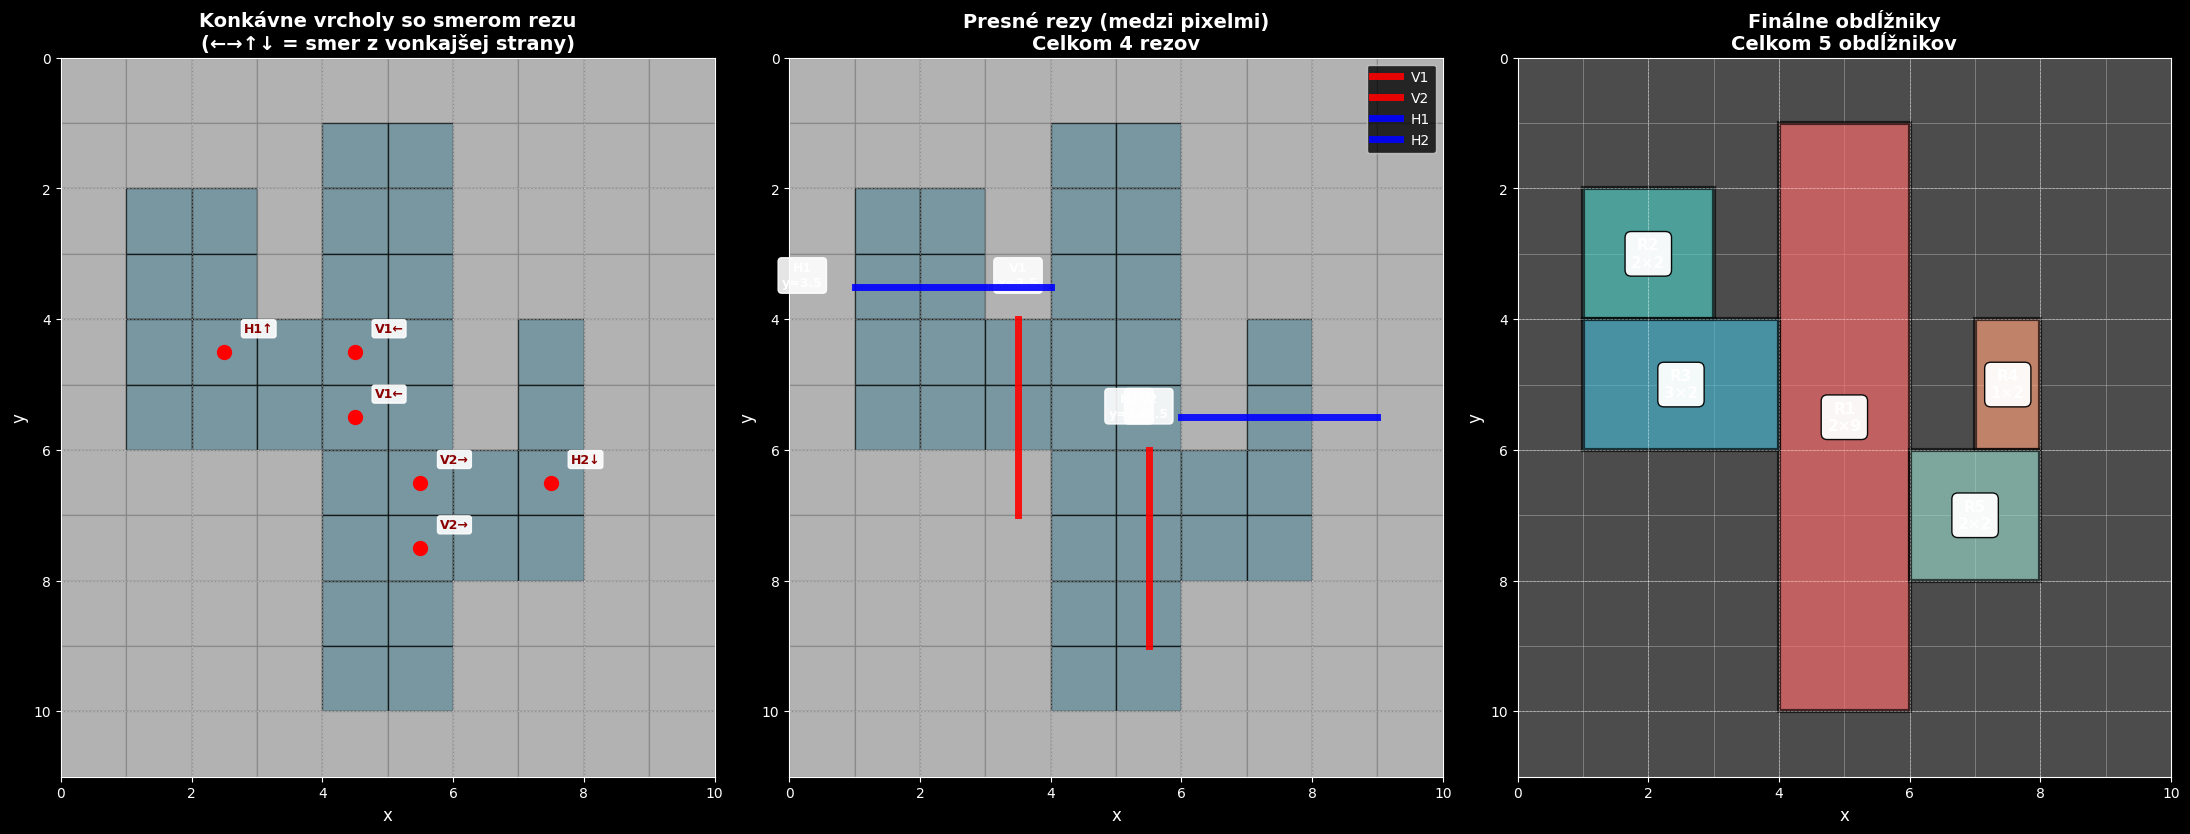

FER ALGORITMUS - PRESNÉ REZY

✂️ Presné rezy (z vonkajšej strany konkávnych vrcholov):

Level 1 (kogrid páry):
  V1: x=3.5 (medzi pixelmi), y=4→6, strana=left
  V2: x=5.5 (medzi pixelmi), y=6→8, strana=right

Level 2 (sekvenčné):
  H1: y=3.5 (medzi pixelmi), x=1→3, strana=top
  H2: y=5.5 (medzi pixelmi), x=6→8, strana=bottom

📦 Obdĺžniky: 5
  R1: (4,1)→(5,9), 2×9, 18px
  R2: (1,2)→(2,3), 2×2, 4px
  R3: (1,4)→(3,5), 3×2, 6px
  R4: (7,4)→(7,5), 1×2, 2px
  R5: (6,6)→(7,7), 2×2, 4px

✅ Pokrytie: 34/34 ✓


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from collections import deque

img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])

# Optimálne rezy s PRESNOU pozíciou (medzi pixelmi)
# Rezy sú definované ako hranice medzi pixelmi

# Level 1: vertikálne kogrid páry
level1_cuts = [
    {
        'type': 'vertical',
        'x_line': 3.5,  # Medzi x=3 a x=4 (z ľavej strany vrcholu 4,4 a 4,5)
        'y_range': (4, 6),  # Od y=4 do y=6 (vrátane)
        'label': 'V1',
        'side': 'left'
    },
    {
        'type': 'vertical',
        'x_line': 5.5,  # Medzi x=5 a x=6 (z pravej strany vrcholu 5,6 a 5,7)
        'y_range': (6, 8),  # Od y=6 do y=8 (vrátane)
        'label': 'V2',
        'side': 'right'
    },
]

# Level 2: sekvenčné rezy zo zvyšných konkávnych vrcholov
level2_cuts = [
    {
        'type': 'horizontal',
        'y_line': 3.5,  # Medzi y=3 a y=4 (z hornej strany vrcholu 2,4)
        'x_range': (1, 3),  # Od x=1 do x=3
        'label': 'H1',
        'side': 'top'
    },
    {
        'type': 'horizontal',
        'y_line': 5.5,  # Medzi y=5 a y=6 (z dolnej strany vrcholu 7,6)
        'x_range': (6, 8),  # Od x=6 do x=8
        'label': 'H2',
        'side': 'bottom'
    },
]

all_cuts = level1_cuts + level2_cuts

def find_rectangles_with_precise_cuts(img, cuts):
    """
    Nájde obdĺžniky s presnými rezmi medzi pixelmi.
    Rezy sú definované ako presné hranice (x.5 alebo y.5).
    """
    rows, cols = img.shape

    # Mapa regiónov
    region_map = np.full((rows, cols), -1, dtype=int)
    region_id = 0

    def is_cut_between(y1, x1, y2, x2):
        """Kontrola, či je medzi dvoma susednými pixelmi rez."""
        for cut in cuts:
            if cut['type'] == 'vertical':
                # Vertikálny rez je medzi stĺpcami
                x_line = cut['x_line']
                y_start, y_end = cut['y_range']

                # Kontrola horizontálneho pohybu cez vertikálny rez
                if y1 == y2 and abs(x1 - x2) == 1:
                    x_border = (min(x1, x2) + max(x1, x2)) / 2.0
                    if abs(x_border - x_line) < 0.1 and y_start <= y1 <= y_end:
                        return True

            else:  # horizontal
                # Horizontálny rez je medzi riadkami
                y_line = cut['y_line']
                x_start, x_end = cut['x_range']

                # Kontrola vertikálneho pohybu cez horizontálny rez
                if x1 == x2 and abs(y1 - y2) == 1:
                    y_border = (min(y1, y2) + max(y1, y2)) / 2.0
                    if abs(y_border - y_line) < 0.1 and x_start <= x1 <= x_end:
                        return True

        return False

    def flood_fill(start_y, start_x, region_id):
        """BFS flood fill - prechádza len cez pixely bez rezov."""
        queue = deque([(start_y, start_x)])
        region_map[start_y, start_x] = region_id
        points = [(start_x, start_y)]

        while queue:
            y, x = queue.popleft()

            # 4-súvislost
            for dy, dx in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                ny, nx = y + dy, x + dx

                if (0 <= ny < rows and 0 <= nx < cols and
                    img[ny, nx] == 1 and
                    region_map[ny, nx] == -1 and
                    not is_cut_between(y, x, ny, nx)):

                    region_map[ny, nx] = region_id
                    queue.append((ny, nx))
                    points.append((nx, ny))

        return points

    rectangles = []

    # Nájdeme všetky regióny
    for i in range(rows):
        for j in range(cols):
            if img[i, j] == 1 and region_map[i, j] == -1:
                points = flood_fill(i, j, region_id)

                if len(points) > 0:
                    xs = [p[0] for p in points]
                    ys = [p[1] for p in points]
                    min_x, max_x = min(xs), max(xs)
                    min_y, max_y = min(ys), max(ys)

                    rectangles.append({
                        'min_x': min_x,
                        'min_y': min_y,
                        'max_x': max_x,
                        'max_y': max_y,
                        'width': max_x - min_x + 1,
                        'height': max_y - min_y + 1,
                        'points': points,
                        'area': len(points)
                    })

                region_id += 1

    return rectangles

# Nájdeme obdĺžniky
rectangles = find_rectangles_with_precise_cuts(img, all_cuts)

# Overenie pokrytia
covered_pixels = set()
for rect in rectangles:
    for point in rect['points']:
        covered_pixels.add(point)

original_pixels = set()
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        if img[i, j] == 1:
            original_pixels.add((j, i))

# Vizualizácia
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

rows, cols = img.shape

# ===== AX1: Pôvodný obraz =====
ax1 = axes[0]
for i in range(rows):
    for j in range(cols):
        color = 'lightblue' if img[i, j] == 1 else 'white'
        rect = Rectangle((j, i), 1, 1, linewidth=1,
                        edgecolor='black' if img[i, j] == 1 else 'gray',
                        facecolor=color, alpha=0.7)
        ax1.add_patch(rect)

# Konkávne vrcholy s označením smeru rezu
concave_info = [
    ((2, 4), 'H1↑'),
    ((4, 4), 'V1←'),
    ((4, 5), 'V1←'),
    ((5, 6), 'V2→'),
    ((7, 6), 'H2↓'),
    ((5, 7), 'V2→'),
]

for (x, y), label in concave_info:
    ax1.plot(x + 0.5, y + 0.5, 'ro', markersize=10, zorder=5)
    ax1.text(x + 0.8, y + 0.2, label, fontsize=9, fontweight='bold',
             color='darkred', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))

ax1.set_xlim(0, cols)
ax1.set_ylim(0, rows)
ax1.set_aspect('equal')
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax1.invert_yaxis()
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Konkávne vrcholy so smerom rezu\n(←→↑↓ = smer z vonkajšej strany)',
             fontsize=14, fontweight='bold')

# ===== AX2: S rezmi =====
ax2 = axes[1]
for i in range(rows):
    for j in range(cols):
        color = 'lightblue' if img[i, j] == 1 else 'white'
        rect = Rectangle((j, i), 1, 1, linewidth=1,
                        edgecolor='black' if img[i, j] == 1 else 'gray',
                        facecolor=color, alpha=0.7)
        ax2.add_patch(rect)

# Vykreslenie rezov ako hrubých čiar PRESNE medzi pixelmi
for cut in all_cuts:
    if cut['type'] == 'vertical':
        x_line = cut['x_line']
        y_start, y_end = cut['y_range']
        color = 'red'
        ax2.plot([x_line, x_line], [y_start, y_end + 1],
                '-', color=color, linewidth=5, label=cut['label'], zorder=5, alpha=0.9)
        # Označenie pozície
        ax2.text(x_line, y_start - 0.5, f"{cut['label']}\nx={x_line}",
                ha='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
    else:  # horizontal
        y_line = cut['y_line']
        x_start, x_end = cut['x_range']
        color = 'blue'
        ax2.plot([x_start, x_end + 1], [y_line, y_line],
                '-', color=color, linewidth=5, label=cut['label'], zorder=5, alpha=0.9)
        # Označenie pozície
        ax2.text(x_start - 0.8, y_line, f"{cut['label']}\ny={y_line}",
                ha='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

ax2.set_xlim(0, cols)
ax2.set_ylim(0, rows)
ax2.set_aspect('equal')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax2.invert_yaxis()
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title(f'Presné rezy (medzi pixelmi)\nCelkom {len(all_cuts)} rezov',
             fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)

# ===== AX3: Finálne obdĺžniky =====
ax3 = axes[2]

# Pozadie
for i in range(rows):
    for j in range(cols):
        rect = Rectangle((j, i), 1, 1, linewidth=0.5, edgecolor='lightgray',
                        facecolor='white', alpha=0.3)
        ax3.add_patch(rect)

# Obdĺžniky
colors_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
                  '#F7DC6F', '#BB8FCE', '#85C1E2']

for idx, rect_data in enumerate(rectangles):
    color = colors_palette[idx % len(colors_palette)]

    rect = Rectangle(
        (rect_data['min_x'], rect_data['min_y']),
        rect_data['width'],
        rect_data['height'],
        linewidth=3,
        edgecolor='black',
        facecolor=color,
        alpha=0.65
    )
    ax3.add_patch(rect)

    center_x = rect_data['min_x'] + rect_data['width'] / 2
    center_y = rect_data['min_y'] + rect_data['height'] / 2

    ax3.text(center_x, center_y, f"R{idx+1}\n{rect_data['width']}×{rect_data['height']}",
            ha='center', va='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.95, edgecolor='black'))

ax3.set_xlim(0, cols)
ax3.set_ylim(0, rows)
ax3.set_aspect('equal')
ax3.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax3.invert_yaxis()
ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel('y', fontsize=12)
ax3.set_title(f'Finálne obdĺžniky\nCelkom {len(rectangles)} obdĺžnikov',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/fer_correct_cuts.png', dpi=150, bbox_inches='tight')
plt.show()

# Výpis
print("=" * 70)
print("FER ALGORITMUS - PRESNÉ REZY")
print("=" * 70)

print(f"\n✂️ Presné rezy (z vonkajšej strany konkávnych vrcholov):")
print(f"\nLevel 1 (kogrid páry):")
for cut in level1_cuts:
    print(f"  {cut['label']}: x={cut['x_line']} (medzi pixelmi), y={cut['y_range'][0]}→{cut['y_range'][1]}, strana={cut['side']}")

print(f"\nLevel 2 (sekvenčné):")
for cut in level2_cuts:
    print(f"  {cut['label']}: y={cut['y_line']} (medzi pixelmi), x={cut['x_range'][0]}→{cut['x_range'][1]}, strana={cut['side']}")

print(f"\n📦 Obdĺžniky: {len(rectangles)}")
for idx, rect in enumerate(rectangles, 1):
    print(f"  R{idx}: ({rect['min_x']},{rect['min_y']})→({rect['max_x']},{rect['max_y']}), {rect['width']}×{rect['height']}, {rect['area']}px")

print(f"\n✅ Pokrytie: {len(covered_pixels)}/{len(original_pixels)} {'✓' if covered_pixels == original_pixels else '✗'}")

In [28]:
import numpy as np
from collections import defaultdict

def find_cogrid_pairs(concave_vertices):
    """
    Nájde kogrid páry - vrcholy so spoločnou x alebo y súradnicou.
    Vracia možné chody (tetivy).
    """
    chords = []

    # Horizontálne páry (rovnaká y-súradnica)
    y_groups = defaultdict(list)
    for vertex in concave_vertices:
        x, y = vertex
        y_groups[y].append(vertex)

    chord_id = 0
    for y, vertices in y_groups.items():
        if len(vertices) >= 2:
            # Vytvoríme chody medzi všetkými pármi v tejto y-súradnici
            for i in range(len(vertices)):
                for j in range(i + 1, len(vertices)):
                    v1, v2 = vertices[i], vertices[j]
                    chords.append({
                        'id': chord_id,
                        'type': 'horizontal',
                        'v1': v1,
                        'v2': v2,
                        'y': y,
                        'x_range': (min(v1[0], v2[0]), max(v1[0], v2[0]))
                    })
                    chord_id += 1

    # Vertikálne páry (rovnaká x-súradnica)
    x_groups = defaultdict(list)
    for vertex in concave_vertices:
        x, y = vertex
        x_groups[x].append(vertex)

    for x, vertices in x_groups.items():
        if len(vertices) >= 2:
            # Vytvoríme chody medzi všetkými pármi v tejto x-súradnici
            for i in range(len(vertices)):
                for j in range(i + 1, len(vertices)):
                    v1, v2 = vertices[i], vertices[j]
                    chords.append({
                        'id': chord_id,
                        'type': 'vertical',
                        'v1': v1,
                        'v2': v2,
                        'x': x,
                        'y_range': (min(v1[1], v2[1]), max(v1[1], v2[1]))
                    })
                    chord_id += 1

    return chords

def chords_intersect(chord1, chord2):
    """
    Kontrola, či sa dve chody pretínajú alebo majú spoločný vrchol.
    """
    # Spoločný vrchol
    if (chord1['v1'] == chord2['v1'] or chord1['v1'] == chord2['v2'] or
        chord1['v2'] == chord2['v1'] or chord1['v2'] == chord2['v2']):
        return True

    # Horizontálne chody sa nikdy nepretínajú medzi sebou
    if chord1['type'] == 'horizontal' and chord2['type'] == 'horizontal':
        return False

    # Vertikálne chody sa nikdy nepretínajú medzi sebou
    if chord1['type'] == 'vertical' and chord2['type'] == 'vertical':
        return False

    # Priesečník horizontálnej a vertikálnej chody
    if chord1['type'] == 'horizontal' and chord2['type'] == 'vertical':
        h_chord, v_chord = chord1, chord2
    else:
        h_chord, v_chord = chord2, chord1

    # Kontrola, či sa pretínajú
    h_y = h_chord['y']
    h_x_min, h_x_max = h_chord['x_range']

    v_x = v_chord['x']
    v_y_min, v_y_max = v_chord['y_range']

    # Pretínajú sa, ak vertikálna chorda prechádza cez horizontálnu
    if h_x_min < v_x < h_x_max and v_y_min < h_y < v_y_max:
        return True

    return False

def build_conflict_graph(chords):
    """
    Vytvorí graf konfliktov - hrana medzi chordami, ktoré sa pretínajú.
    Vracia adjacency list.
    """
    graph = defaultdict(list)

    for i, chord1 in enumerate(chords):
        for j, chord2 in enumerate(chords):
            if i != j and chords_intersect(chord1, chord2):
                graph[chord1['id']].append(chord2['id'])

    return graph

def is_bipartite_graph(chords, graph):
    """
    Overí, či je graf bipartitný (všetky horizontálne vs všetky vertikálne).
    """
    # V našom prípade je graf VŽDY bipartitný, pretože:
    # - horizontálne chody sa nepretínajú medzi sebou
    # - vertikálne chody sa nepretínajú medzi sebou
    # - len horizontal-vertical môžu mať hrany
    return True

def maximum_matching_bipartite(chords, graph):
    """
    Nájde maximálne párovanie v bipartitnom grafe.
    Používa augmenting path algoritmus (DFS-based).
    """
    # Rozdelíme chody na dve množiny
    horizontal = [c for c in chords if c['type'] == 'horizontal']
    vertical = [c for c in chords if c['type'] == 'vertical']

    # Matching: chord_id -> matched_chord_id
    matching = {}

    def dfs_augmenting_path(chord_id, visited):
        """DFS na nájdenie augmentujúcej cesty."""
        for neighbor_id in graph[chord_id]:
            if neighbor_id in visited:
                continue

            visited.add(neighbor_id)

            # Ak sused nie je matchnutý, alebo môžeme nájsť alternatívnu cestu
            if neighbor_id not in matching or dfs_augmenting_path(matching[neighbor_id], visited):
                matching[chord_id] = neighbor_id
                matching[neighbor_id] = chord_id
                return True

        return False

    # Pre každú horizontálnu chodu hľadáme augmentujúcu cestu
    for h_chord in horizontal:
        visited = set()
        dfs_augmenting_path(h_chord['id'], visited)

    # Matching obsahuje páry (každý pár je tam 2x)
    matched_pairs = set()
    for chord_id, matched_id in matching.items():
        pair = tuple(sorted([chord_id, matched_id]))
        matched_pairs.add(pair)

    return matched_pairs

def maximum_independent_set(chords, graph, matching_pairs):
    """
    Nájde maximálnu nezávislú množinu z maximálneho párovania.

    MIS obsahuje:
    1. Jeden vrchol z každého matchovaného páru
    2. Všetky izolované vrcholy (bez hran)
    3. Niektoré ďalšie vrcholy, ktoré nie sú v matchingu ale sú nezávislé
    """
    # Množina všetkých chord IDs
    all_chord_ids = {c['id'] for c in chords}

    # Chord IDs, ktoré sú v matchingu
    matched_chord_ids = set()
    for pair in matching_pairs:
        matched_chord_ids.add(pair[0])
        matched_chord_ids.add(pair[1])

    # Izolované vrcholy (bez hran)
    isolated = set()
    for chord in chords:
        if len(graph[chord['id']]) == 0:
            isolated.add(chord['id'])

    # Vrcholy, ktoré nie sú v matchingu
    unmatched = all_chord_ids - matched_chord_ids

    # MIS: vyberieme jeden z každého páru + izolované + niektoré unmatched
    mis = set()

    # 1. Izolované vrcholy (vždy ich pridáme)
    mis.update(isolated)

    # 2. Jeden z každého matchovaného páru (vyberieme prvý)
    for pair in matching_pairs:
        mis.add(pair[0])  # Môžeme vybrať ľubovoľný z páru

    # 3. Unmatched vrcholy, ktoré sú nezávislé od už vybraných
    for chord_id in unmatched:
        # Skontrolujeme, či je nezávislý od všetkých už vybraných
        is_independent = True
        for selected_id in mis:
            if selected_id in graph[chord_id]:
                is_independent = False
                break

        if is_independent:
            mis.add(chord_id)

    return mis

def fer_algorithm_mis(concave_vertices):
    """
    Hlavný FER algoritmus - Level 1 pomocou MIS.
    """
    print("=" * 70)
    print("FER ALGORITMUS - MAXIMUM INDEPENDENT SET")
    print("=" * 70)

    # Krok 1: Nájdeme kogrid páry (možné chody)
    chords = find_cogrid_pairs(concave_vertices)

    print(f"\n📍 Konkávne vrcholy: {len(concave_vertices)}")
    for v in concave_vertices:
        print(f"  • {v}")

    print(f"\n🎯 Možné chody (kogrid páry): {len(chords)}")
    for chord in chords:
        if chord['type'] == 'horizontal':
            print(f"  Chord {chord['id']}: {chord['v1']} ↔ {chord['v2']} (horizontal, y={chord['y']})")
        else:
            print(f"  Chord {chord['id']}: {chord['v1']} ↔ {chord['v2']} (vertical, x={chord['x']})")

    # Krok 2: Vytvoríme konfliktový graf
    graph = build_conflict_graph(chords)

    print(f"\n🔗 Konfliktový graf (hrany = priesečníky):")
    for chord_id, neighbors in graph.items():
        if neighbors:
            print(f"  Chord {chord_id} konfliktuje s: {neighbors}")

    # Krok 3: Overíme bipartitnosť
    is_bip = is_bipartite_graph(chords, graph)
    print(f"\n✓ Graf je bipartitný: {is_bip}")

    # Krok 4: Nájdeme maximálne párovanie
    matching_pairs = maximum_matching_bipartite(chords, graph)

    print(f"\n🔄 Maximálne párovanie: {len(matching_pairs)} párov")
    for pair in matching_pairs:
        chord1 = next(c for c in chords if c['id'] == pair[0])
        chord2 = next(c for c in chords if c['id'] == pair[1])
        print(f"  Pár: Chord {pair[0]} ↔ Chord {pair[1]}")

    # Krok 5: Nájdeme maximálnu nezávislú množinu
    mis = maximum_independent_set(chords, graph, matching_pairs)

    print(f"\n⭐ Maximálna nezávislá množina (MIS): {len(mis)} chôrd")
    selected_chords = [c for c in chords if c['id'] in mis]

    for chord in selected_chords:
        if chord['type'] == 'horizontal':
            print(f"  ✓ Chord {chord['id']}: {chord['v1']} ↔ {chord['v2']} (horizontal, y={chord['y']})")
        else:
            print(f"  ✓ Chord {chord['id']}: {chord['v1']} ↔ {chord['v2']} (vertical, x={chord['x']})")

    # Krok 6: Identifikujeme zvyšné konkávne vrcholy
    used_vertices = set()
    for chord in selected_chords:
        used_vertices.add(chord['v1'])
        used_vertices.add(chord['v2'])

    remaining_vertices = [v for v in concave_vertices if v not in used_vertices]

    print(f"\n📌 Zvyšné konkávne vrcholy (pre Level 2): {len(remaining_vertices)}")
    for v in remaining_vertices:
        print(f"  • {v}")

    print(f"\n✅ Level 1 dokončený: {len(selected_chords)} rezov z MIS")
    print(f"✅ Level 2 potrebuje: {len(remaining_vertices)} rezov")
    print(f"✅ Celkový počet rezov: {len(selected_chords) + len(remaining_vertices)}")

    return selected_chords, remaining_vertices

# Test
concave_vertices = [
    (2, 4),
    (4, 4),
    (4, 5),
    (5, 6),
    (7, 6),
    (5, 7),
]

concave_vertices = [(89, 3), (88, 7), (97, 7), (86, 8), (99, 8), (85, 9), (84, 10), (135, 10), (139, 10), (134, 11), (38, 12), (45, 12), (83, 12), (100, 12), (141, 12), (46, 13), (50, 14), (101, 14), (52, 15), (133, 15), (54, 16), (130, 16), (129, 17), (55, 18), (128, 18), (142, 18), (57, 20), (144, 20), (127, 21), (83, 22), (145, 22), (102, 23), (101, 24), (84, 25), (127, 25), (86, 26), (99, 26), (87, 27), (98, 27), (145, 27), (7, 28), (38, 28), (57, 28), (88, 28), (97, 28), (128, 28), (8, 29), (144, 29), (13, 30), (16, 31), (39, 31), (143, 31), (18, 32), (41, 32), (141, 32), (43, 33), (139, 33), (173, 33), (177, 33), (19, 34), (47, 34), (138, 34), (172, 35), (48, 36), (57, 36), (97, 36), (137, 36), (166, 36), (128, 37), (136, 37), (165, 37), (58, 38), (49, 39), (50, 40), (88, 40), (127, 40), (164, 40), (3, 41), (135, 41), (51, 42), (87, 42), (98, 42), (134, 42), (59, 43), (126, 43), (99, 44), (133, 44), (4, 45), (20, 45), (60, 45), (86, 45), (125, 45), (5, 46), (85, 46), (100, 46), (132, 46), (7, 47), (21, 47), (84, 47), (105, 47), (124, 47), (8, 48), (61, 48), (79, 48), (110, 48), (123, 48), (131, 48), (163, 48), (15, 49), (22, 49), (62, 49), (74, 49), (112, 49), (122, 49), (162, 49), (23, 50), (63, 50), (71, 50), (161, 50), (16, 51), (24, 51), (160, 51), (177, 51), (25, 52), (159, 52), (176, 52), (18, 53), (26, 53), (51, 53), (158, 53), (174, 53), (27, 54), (49, 54), (131, 54), (157, 54), (167, 54), (19, 55), (28, 55), (48, 55), (156, 55), (165, 55), (20, 56), (29, 56), (44, 56), (132, 56), (155, 56), (21, 57), (30, 57), (41, 57), (133, 57), (154, 57), (164, 57), (31, 58), (39, 58), (135, 58), (153, 58), (163, 58), (22, 59), (137, 59), (152, 59), (162, 59), (23, 60), (138, 60), (151, 60), (161, 60), (24, 61), (140, 61), (149, 61), (160, 61), (159, 62), (25, 63), (158, 63), (26, 64), (157, 65), (27, 66), (156, 66), (155, 67), (154, 68), (153, 69), (28, 74), (31, 76), (152, 76), (151, 78), (147, 79), (146, 80), (32, 86), (33, 87), (35, 88), (145, 89), (143, 90), (142, 91), (36, 102), (37, 103), (141, 103), (39, 104), (140, 104), (40, 105), (139, 105), (44, 106), (138, 106), (46, 107), (132, 107), (50, 108), (128, 108), (55, 109), (122, 109)]



selected_chords, remaining_vertices = fer_algorithm_mis(concave_vertices)

# Vizualizácia vybraných chôrd
print("\n" + "=" * 70)
print("VÝSLEDOK MIS")
print("=" * 70)
print("\n🎯 Vybrané chody pre Level 1:")
for i, chord in enumerate(selected_chords, 1):
    print(f"  {i}. {chord['v1']} ↔ {chord['v2']} ({chord['type']})")

print("\n📋 Pre Level 2 treba dokončiť:")
for v in remaining_vertices:
    print(f"  • Vrchol {v}")

FER ALGORITMUS - MAXIMUM INDEPENDENT SET

📍 Konkávne vrcholy: 206
  • (89, 3)
  • (88, 7)
  • (97, 7)
  • (86, 8)
  • (99, 8)
  • (85, 9)
  • (84, 10)
  • (135, 10)
  • (139, 10)
  • (134, 11)
  • (38, 12)
  • (45, 12)
  • (83, 12)
  • (100, 12)
  • (141, 12)
  • (46, 13)
  • (50, 14)
  • (101, 14)
  • (52, 15)
  • (133, 15)
  • (54, 16)
  • (130, 16)
  • (129, 17)
  • (55, 18)
  • (128, 18)
  • (142, 18)
  • (57, 20)
  • (144, 20)
  • (127, 21)
  • (83, 22)
  • (145, 22)
  • (102, 23)
  • (101, 24)
  • (84, 25)
  • (127, 25)
  • (86, 26)
  • (99, 26)
  • (87, 27)
  • (98, 27)
  • (145, 27)
  • (7, 28)
  • (38, 28)
  • (57, 28)
  • (88, 28)
  • (97, 28)
  • (128, 28)
  • (8, 29)
  • (144, 29)
  • (13, 30)
  • (16, 31)
  • (39, 31)
  • (143, 31)
  • (18, 32)
  • (41, 32)
  • (141, 32)
  • (43, 33)
  • (139, 33)
  • (173, 33)
  • (177, 33)
  • (19, 34)
  • (47, 34)
  • (138, 34)
  • (172, 35)
  • (48, 36)
  • (57, 36)
  • (97, 36)
  • (137, 36)
  • (166, 36)
  • (128, 37)
  • (136, 37)
 

ALTERNATÍVNE RIEŠENIE: H1, H2

Level 1 - vybrané chody:
  H1: spája [(2, 4), (4, 4)]
  H2: spája [(5, 6), (7, 6)]

Zvyšné konkávne vrcholy:
  • (4, 5)
  • (5, 7)

Level 2 - sekvenčné rezy:
  V1: z vrcholu (4, 5), vertical na 3.5
  V2: z vrcholu (5, 7), vertical na 5.5


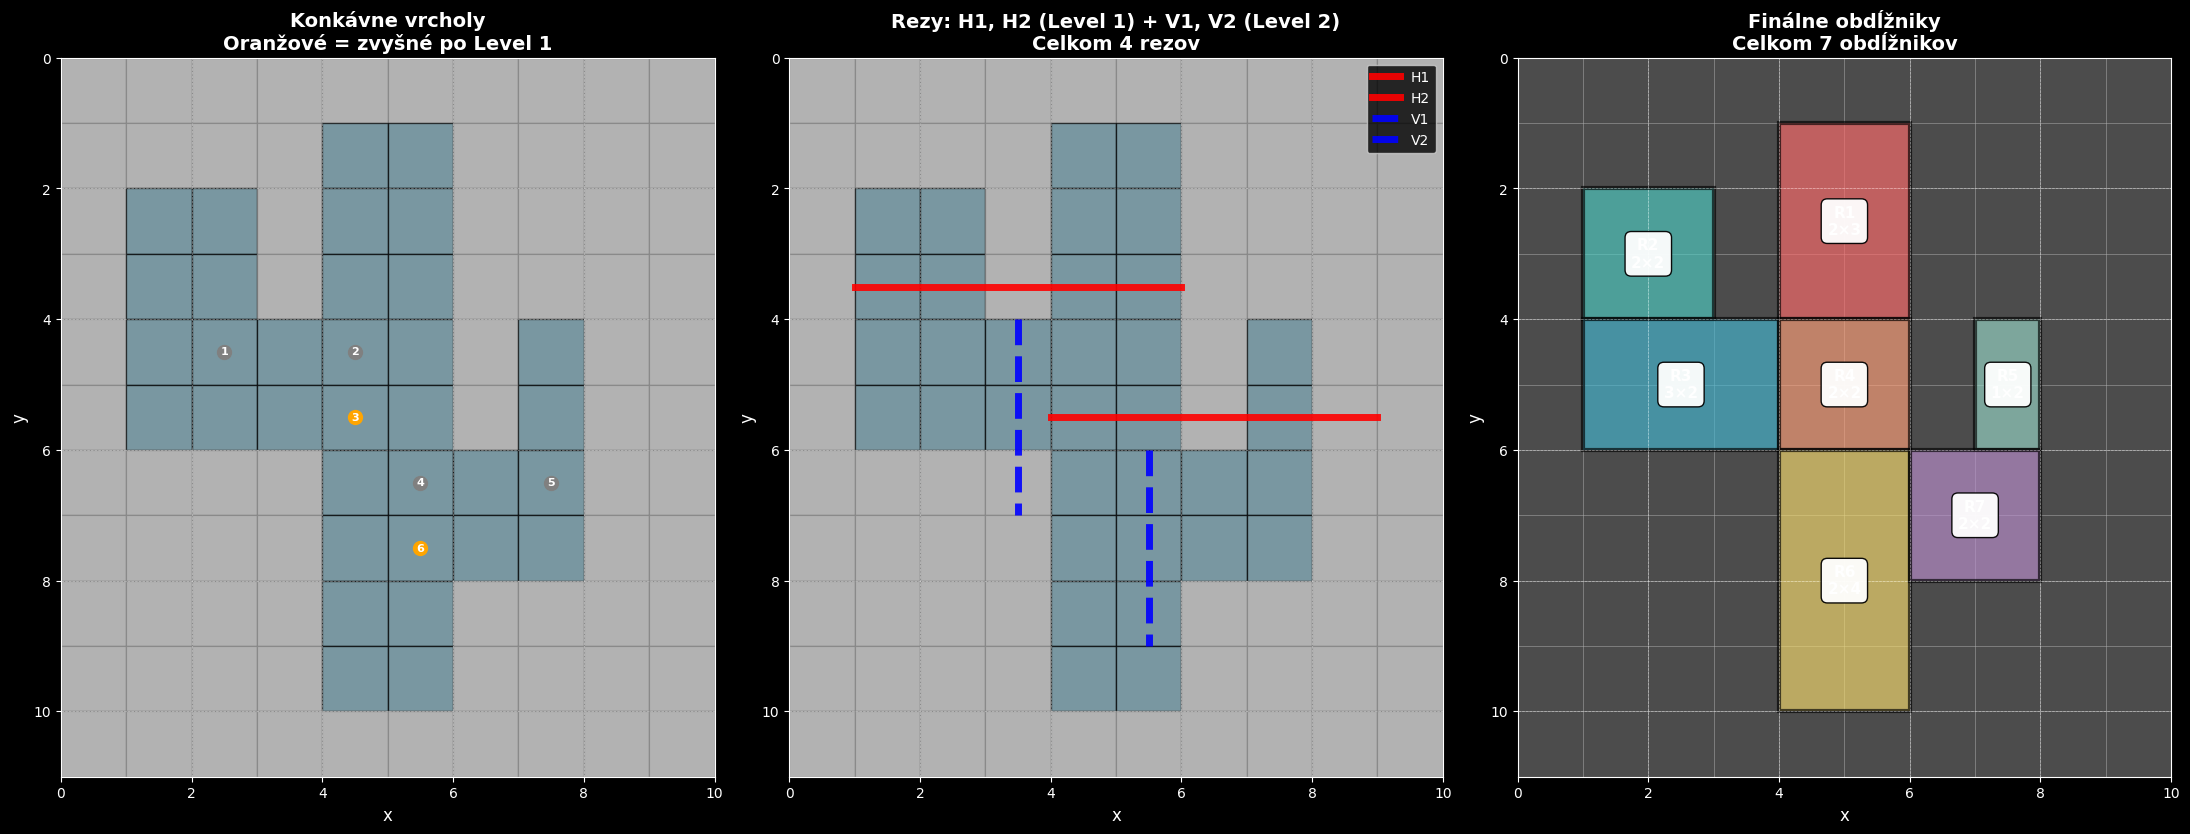


📦 Finálne obdĺžniky: 7
  R1: (4,1)→(5,3), 2×3, 6px
  R2: (1,2)→(2,3), 2×2, 4px
  R3: (1,4)→(3,5), 3×2, 6px
  R4: (4,4)→(5,5), 2×2, 4px
  R5: (7,4)→(7,5), 1×2, 2px
  R6: (4,6)→(5,9), 2×4, 8px
  R7: (6,6)→(7,7), 2×2, 4px

✅ Celkový počet rezov: 2 (Level 1) + 2 (Level 2) = 4
✅ Obe riešenia (H1+H2 vs V1+V2) majú rovnaký počet rezov = OPTIMÁLNE


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from collections import deque

img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])

# Konkávne vrcholy
concave_vertices = [
    (2, 4),  # 1
    (4, 4),  # 2
    (4, 5),  # 3
    (5, 6),  # 4
    (7, 6),  # 5
    (5, 7),  # 6
]

# ALTERNATÍVNE RIEŠENIE: Zvolíme H1, H2 (horizontálne kogrid páry)
# Level 1: horizontálne kogrid páry
level1_cuts = [
    {
        'type': 'horizontal',
        'y_line': 3.5,  # Medzi y=3 a y=4 (spája vrcholy (2,4) a (4,4))
        'x_range': (1, 5),  # Od x=1 do x=5 (celá dĺžka)
        'label': 'H1',
        'used_vertices': [(2, 4), (4, 4)]
    },
    {
        'type': 'horizontal',
        'y_line': 5.5,  # Medzi y=5 a y=6 (spája vrcholy (5,6) a (7,6))
        'x_range': (4, 8),  # Od x=4 do x=8
        'label': 'H2',
        'used_vertices': [(5, 6), (7, 6)]
    },
]

# Zvyšné konkávne vrcholy po Level 1
used_vertices = set()
for cut in level1_cuts:
    used_vertices.update(cut['used_vertices'])

remaining_vertices = [v for v in concave_vertices if v not in used_vertices]
print("=" * 70)
print("ALTERNATÍVNE RIEŠENIE: H1, H2")
print("=" * 70)
print(f"\nLevel 1 - vybrané chody:")
for cut in level1_cuts:
    print(f"  {cut['label']}: spája {cut['used_vertices']}")

print(f"\nZvyšné konkávne vrcholy:")
for v in remaining_vertices:
    print(f"  • {v}")

# Level 2: sekvenčné rezy zo zvyšných vrcholov
# Zostali: (4,5) a (5,7)

level2_cuts = [
    {
        'type': 'vertical',
        'x_line': 3.5,  # Z ľavej strany vrcholu (4,5)
        'y_range': (4, 6),  # Musí ísť cez objekt
        'label': 'V1',
        'from_vertex': (4, 5)
    },
    {
        'type': 'vertical',
        'x_line': 5.5,  # Z pravej strany vrcholu (5,7)
        'y_range': (6, 8),
        'label': 'V2',
        'from_vertex': (5, 7)
    },
]

print(f"\nLevel 2 - sekvenčné rezy:")
for cut in level2_cuts:
    print(f"  {cut['label']}: z vrcholu {cut['from_vertex']}, {cut['type']} na {cut.get('x_line', cut.get('y_line'))}")

all_cuts = level1_cuts + level2_cuts

def find_rectangles_with_precise_cuts(img, cuts):
    """
    Nájde obdĺžniky s presnými rezmi medzi pixelmi.
    """
    rows, cols = img.shape
    region_map = np.full((rows, cols), -1, dtype=int)
    region_id = 0

    def is_cut_between(y1, x1, y2, x2):
        """Kontrola, či je medzi dvoma susednými pixelmi rez."""
        for cut in cuts:
            if cut['type'] == 'vertical':
                x_line = cut['x_line']
                y_start, y_end = cut['y_range']

                if y1 == y2 and abs(x1 - x2) == 1:
                    x_border = (min(x1, x2) + max(x1, x2)) / 2.0
                    if abs(x_border - x_line) < 0.1 and y_start <= y1 <= y_end:
                        return True

            else:  # horizontal
                y_line = cut['y_line']
                x_start, x_end = cut['x_range']

                if x1 == x2 and abs(y1 - y2) == 1:
                    y_border = (min(y1, y2) + max(y1, y2)) / 2.0
                    if abs(y_border - y_line) < 0.1 and x_start <= x1 <= x_end:
                        return True

        return False

    def flood_fill(start_y, start_x, region_id):
        """BFS flood fill."""
        queue = deque([(start_y, start_x)])
        region_map[start_y, start_x] = region_id
        points = [(start_x, start_y)]

        while queue:
            y, x = queue.popleft()

            for dy, dx in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                ny, nx = y + dy, x + dx

                if (0 <= ny < rows and 0 <= nx < cols and
                    img[ny, nx] == 1 and
                    region_map[ny, nx] == -1 and
                    not is_cut_between(y, x, ny, nx)):

                    region_map[ny, nx] = region_id
                    queue.append((ny, nx))
                    points.append((nx, ny))

        return points

    rectangles = []

    for i in range(rows):
        for j in range(cols):
            if img[i, j] == 1 and region_map[i, j] == -1:
                points = flood_fill(i, j, region_id)

                if len(points) > 0:
                    xs = [p[0] for p in points]
                    ys = [p[1] for p in points]
                    min_x, max_x = min(xs), max(xs)
                    min_y, max_y = min(ys), max(ys)

                    rectangles.append({
                        'min_x': min_x,
                        'min_y': min_y,
                        'max_x': max_x,
                        'max_y': max_y,
                        'width': max_x - min_x + 1,
                        'height': max_y - min_y + 1,
                        'points': points,
                        'area': len(points)
                    })

                region_id += 1

    return rectangles

# Nájdeme obdĺžniky
rectangles = find_rectangles_with_precise_cuts(img, all_cuts)

# Vizualizácia
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
rows, cols = img.shape

# ===== AX1: Pôvodný obraz =====
ax1 = axes[0]
for i in range(rows):
    for j in range(cols):
        color = 'lightblue' if img[i, j] == 1 else 'white'
        rect = Rectangle((j, i), 1, 1, linewidth=1,
                        edgecolor='black' if img[i, j] == 1 else 'gray',
                        facecolor=color, alpha=0.7)
        ax1.add_patch(rect)

# Konkávne vrcholy s označením
for idx, v in enumerate(concave_vertices, 1):
    x, y = v
    color = 'orange' if v in remaining_vertices else 'gray'
    ax1.plot(x + 0.5, y + 0.5, 'o', color=color, markersize=10, zorder=5)
    ax1.text(x + 0.5, y + 0.5, str(idx), ha='center', va='center',
             fontsize=8, color='white', fontweight='bold', zorder=6)

ax1.set_xlim(0, cols)
ax1.set_ylim(0, rows)
ax1.set_aspect('equal')
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax1.invert_yaxis()
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Konkávne vrcholy\nOranžové = zvyšné po Level 1',
             fontsize=14, fontweight='bold')

# ===== AX2: S rezmi =====
ax2 = axes[1]
for i in range(rows):
    for j in range(cols):
        color = 'lightblue' if img[i, j] == 1 else 'white'
        rect = Rectangle((j, i), 1, 1, linewidth=1,
                        edgecolor='black' if img[i, j] == 1 else 'gray',
                        facecolor=color, alpha=0.7)
        ax2.add_patch(rect)

# Vykreslenie rezov
for cut in all_cuts:
    if cut['type'] == 'vertical':
        x_line = cut['x_line']
        y_start, y_end = cut['y_range']
        color = 'blue'
        linestyle = '--'
        ax2.plot([x_line, x_line], [y_start, y_end + 1],
                linestyle, color=color, linewidth=5, label=cut['label'], zorder=5, alpha=0.9)
    else:  # horizontal
        y_line = cut['y_line']
        x_start, x_end = cut['x_range']
        color = 'red'
        linestyle = '-'
        ax2.plot([x_start, x_end + 1], [y_line, y_line],
                linestyle, color=color, linewidth=5, label=cut['label'], zorder=5, alpha=0.9)

ax2.set_xlim(0, cols)
ax2.set_ylim(0, rows)
ax2.set_aspect('equal')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax2.invert_yaxis()
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title(f'Rezy: H1, H2 (Level 1) + V1, V2 (Level 2)\nCelkom {len(all_cuts)} rezov',
             fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)

# ===== AX3: Finálne obdĺžniky =====
ax3 = axes[2]

for i in range(rows):
    for j in range(cols):
        rect = Rectangle((j, i), 1, 1, linewidth=0.5, edgecolor='lightgray',
                        facecolor='white', alpha=0.3)
        ax3.add_patch(rect)

colors_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
                  '#F7DC6F', '#BB8FCE', '#85C1E2']

for idx, rect_data in enumerate(rectangles):
    color = colors_palette[idx % len(colors_palette)]

    rect = Rectangle(
        (rect_data['min_x'], rect_data['min_y']),
        rect_data['width'],
        rect_data['height'],
        linewidth=3,
        edgecolor='black',
        facecolor=color,
        alpha=0.65
    )
    ax3.add_patch(rect)

    center_x = rect_data['min_x'] + rect_data['width'] / 2
    center_y = rect_data['min_y'] + rect_data['height'] / 2

    ax3.text(center_x, center_y, f"R{idx+1}\n{rect_data['width']}×{rect_data['height']}",
            ha='center', va='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.95, edgecolor='black'))

ax3.set_xlim(0, cols)
ax3.set_ylim(0, rows)
ax3.set_aspect('equal')
ax3.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax3.invert_yaxis()
ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel('y', fontsize=12)
ax3.set_title(f'Finálne obdĺžniky\nCelkom {len(rectangles)} obdĺžnikov',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/fer_alternative_h1h2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📦 Finálne obdĺžniky: {len(rectangles)}")
for idx, rect in enumerate(rectangles, 1):
    print(f"  R{idx}: ({rect['min_x']},{rect['min_y']})→({rect['max_x']},{rect['max_y']}), "
          f"{rect['width']}×{rect['height']}, {rect['area']}px")

print(f"\n✅ Celkový počet rezov: {len(level1_cuts)} (Level 1) + {len(level2_cuts)} (Level 2) = {len(all_cuts)}")
print(f"✅ Obe riešenia (H1+H2 vs V1+V2) majú rovnaký počet rezov = OPTIMÁLNE")

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from collections import deque, defaultdict

# Tu vložíš celý tvoj MIS kód z dokumentu 4
# ...
# (find_cogrid_pairs, chords_intersect, build_conflict_graph, atď.)

def determine_cut_direction(vertex, img, existing_cuts):
    """
    Určí smer rezu z konkávneho vrcholu pre Level 2.
    Rez ide von z objektu, končí na hranici alebo na existujúcej chorde.
    """
    x, y = vertex
    rows, cols = img.shape

    # Možné smery: hore, dole, vľavo, vpravo
    directions = [
        ('up', 0, -1, 'vertical'),
        ('down', 0, 1, 'vertical'),
        ('left', -1, 0, 'horizontal'),
        ('right', 1, 0, 'horizontal')
    ]

    for dir_name, dx, dy, cut_type in directions:
        # Kontrola, či rez ide VON z objektu (do pozadia)
        nx, ny = x + dx, y + dy

        if 0 <= nx < cols and 0 <= ny < rows:
            # Ak ide do pozadia (0), to je správny smer
            if img[ny, nx] == 0:
                # Nájdeme range rezu
                if cut_type == 'horizontal':
                    # Horizontálny rez
                    if dir_name == 'left':
                        # Hľadáme najľavejší bod
                        end_x = x
                        while end_x >= 0 and img[y, end_x] == 1:
                            end_x -= 1
                        return {
                            'type': 'horizontal',
                            'y_line': y - 0.5 if dy < 0 else y + 0.5,
                            'x_range': (end_x + 1, x),
                            'from_vertex': vertex,
                            'direction': dir_name
                        }
                    else:  # right
                        end_x = x
                        while end_x < cols and img[y, end_x] == 1:
                            end_x += 1
                        return {
                            'type': 'horizontal',
                            'y_line': y - 0.5 if dy < 0 else y + 0.5,
                            'x_range': (x, end_x - 1),
                            'from_vertex': vertex,
                            'direction': dir_name
                        }
                else:  # vertical
                    if dir_name == 'up':
                        end_y = y
                        while end_y >= 0 and img[end_y, x] == 1:
                            end_y -= 1
                        return {
                            'type': 'vertical',
                            'x_line': x - 0.5 if dx < 0 else x + 0.5,
                            'y_range': (end_y + 1, y),
                            'from_vertex': vertex,
                            'direction': dir_name
                        }
                    else:  # down
                        end_y = y
                        while end_y < rows and img[end_y, x] == 1:
                            end_y += 1
                        return {
                            'type': 'vertical',
                            'x_line': x - 0.5 if dx < 0 else x + 0.5,
                            'y_range': (y, end_y - 1),
                            'from_vertex': vertex,
                            'direction': dir_name
                        }

    return None

def create_level2_cuts(remaining_vertices, img, level1_chords):
    """
    Vytvorí Level 2 rezy zo zvyšných konkávnych vrcholov.
    """
    level2_cuts = []

    for vertex in remaining_vertices:
        cut = determine_cut_direction(vertex, img, level1_chords)
        if cut:
            level2_cuts.append(cut)

    return level2_cuts

def chords_to_cuts(selected_chords):
    """
    Konvertuje chords z MIS na formát cuts pre vizualizáciu.
    """
    level1_cuts = []

    for chord in selected_chords:
        if chord['type'] == 'horizontal':
            y = chord['y']
            x_min, x_max = chord['x_range']
            # Určíme, kde presne je rez (medzi pixelmi)
            cut = {
                'type': 'horizontal',
                'y_line': y + 0.5,  # Rez je pod riadkom y
                'x_range': (x_min, x_max),
                'label': f"H{len(level1_cuts)}",
                'chord': chord
            }
        else:  # vertical
            x = chord['x']
            y_min, y_max = chord['y_range']
            cut = {
                'type': 'vertical',
                'x_line': x + 0.5,  # Rez je napravo od stĺpca x
                'y_range': (y_min, y_max),
                'label': f"V{len(level1_cuts)}",
                'chord': chord
            }

        level1_cuts.append(cut)

    return level1_cuts

def find_rectangles_with_precise_cuts(img, cuts):
    """
    Nájde obdĺžniky s presnými rezmi medzi pixelmi.
    """
    rows, cols = img.shape
    region_map = np.full((rows, cols), -1, dtype=int)
    region_id = 0

    def is_cut_between(y1, x1, y2, x2):
        """Kontrola, či je medzi dvoma susednými pixelmi rez."""
        for cut in cuts:
            if cut['type'] == 'vertical':
                x_line = cut['x_line']
                y_start, y_end = cut['y_range']

                if y1 == y2 and abs(x1 - x2) == 1:
                    x_border = (min(x1, x2) + max(x1, x2)) / 2.0
                    if abs(x_border - x_line) < 0.1 and y_start <= y1 <= y_end:
                        return True

            else:  # horizontal
                y_line = cut['y_line']
                x_start, x_end = cut['x_range']

                if x1 == x2 and abs(y1 - y2) == 1:
                    y_border = (min(y1, y2) + max(y1, y2)) / 2.0
                    if abs(y_border - y_line) < 0.1 and x_start <= x1 <= x_end:
                        return True

        return False

    def flood_fill(start_y, start_x, region_id):
        """BFS flood fill."""
        queue = deque([(start_y, start_x)])
        region_map[start_y, start_x] = region_id
        points = [(start_x, start_y)]

        while queue:
            y, x = queue.popleft()

            for dy, dx in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                ny, nx = y + dy, x + dx

                if (0 <= ny < rows and 0 <= nx < cols and
                    img[ny, nx] == 1 and
                    region_map[ny, nx] == -1 and
                    not is_cut_between(y, x, ny, nx)):

                    region_map[ny, nx] = region_id
                    queue.append((ny, nx))
                    points.append((nx, ny))

        return points

    rectangles = []

    for i in range(rows):
        for j in range(cols):
            if img[i, j] == 1 and region_map[i, j] == -1:
                points = flood_fill(i, j, region_id)

                if len(points) > 0:
                    xs = [p[0] for p in points]
                    ys = [p[1] for p in points]
                    min_x, max_x = min(xs), max(xs)
                    min_y, max_y = min(ys), max(ys)

                    rectangles.append({
                        'min_x': min_x,
                        'min_y': min_y,
                        'max_x': max_x,
                        'max_y': max_y,
                        'width': max_x - min_x + 1,
                        'height': max_y - min_y + 1,
                        'points': points,
                        'area': len(points)
                    })

                region_id += 1

    return rectangles

# ===== HLAVNÝ KÓD =====

# 1. Získame MIS výsledok
concave_vertices = [
    (2, 4), (4, 4), (4, 5), (5, 6), (7, 6), (5, 7)
]

img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])

# Spustíme MIS algoritmus (z dokumentu 4)
selected_chords, remaining_vertices = fer_algorithm_mis(concave_vertices)

print("\n" + "=" * 70)
print("APLIKÁCIA REZOV")
print("=" * 70)

# 2. Konvertujeme Level 1 chords na cuts
level1_cuts = chords_to_cuts(selected_chords)
print(f"\n✅ Level 1 cuts: {len(level1_cuts)}")

# 3. Vytvoríme Level 2 cuts
level2_cuts = create_level2_cuts(remaining_vertices, img, selected_chords)
print(f"✅ Level 2 cuts: {len(level2_cuts)}")

# 4. Spojíme všetky cuts
all_cuts = level1_cuts + level2_cuts

# 5. Nájdeme obdĺžniky
rectangles = find_rectangles_with_precise_cuts(img, all_cuts)

print(f"\n📦 Finálne obdĺžniky: {len(rectangles)}")
for idx, rect in enumerate(rectangles, 1):
    print(f"  R{idx}: ({rect['min_x']},{rect['min_y']})→({rect['max_x']},{rect['max_y']}), "
          f"{rect['width']}×{rect['height']}, {rect['area']}px")

# Overenie pokrytia
covered = sum(r['area'] for r in rectangles)
original = np.sum(img == 1)
print(f"\n✅ Pokrytie: {covered}/{original} {'✓' if covered == original else '✗'}")

FER ALGORITMUS - MAXIMUM INDEPENDENT SET

📍 Konkávne vrcholy: 6
  • (2, 4)
  • (4, 4)
  • (4, 5)
  • (5, 6)
  • (7, 6)
  • (5, 7)

🎯 Možné chody (kogrid páry): 4
  Chord 0: (2, 4) ↔ (4, 4) (horizontal, y=4)
  Chord 1: (5, 6) ↔ (7, 6) (horizontal, y=6)
  Chord 2: (4, 4) ↔ (4, 5) (vertical, x=4)
  Chord 3: (5, 6) ↔ (5, 7) (vertical, x=5)

🔗 Konfliktový graf (hrany = priesečníky):
  Chord 0 konfliktuje s: [2]
  Chord 1 konfliktuje s: [3]
  Chord 2 konfliktuje s: [0]
  Chord 3 konfliktuje s: [1]

✓ Graf je bipartitný: True

🔄 Maximálne párovanie: 2 párov
  Pár: Chord 0 ↔ Chord 2
  Pár: Chord 1 ↔ Chord 3

⭐ Maximálna nezávislá množina (MIS): 2 chôrd
  ✓ Chord 0: (2, 4) ↔ (4, 4) (horizontal, y=4)
  ✓ Chord 1: (5, 6) ↔ (7, 6) (horizontal, y=6)

📌 Zvyšné konkávne vrcholy (pre Level 2): 2
  • (4, 5)
  • (5, 7)

✅ Level 1 dokončený: 2 rezov z MIS
✅ Level 2 potrebuje: 2 rezov
✅ Celkový počet rezov: 4

APLIKÁCIA REZOV

✅ Level 1 cuts: 2
✅ Level 2 cuts: 0

📦 Finálne obdĺžniky: 1
  R1: (1,1)→(7,9), 